# S5 — Main Models

## Pregled

| # | Model | Tip | Opis |
|---|-------|-----|------|
| 1 | **XGBoost** | Gradient Boosting | Brz, visoke performanse, podrška za regularizaciju |
| 2 | **LightGBM** | Gradient Boosting | Leaf-wise rast, optimiziran za velike datasete |
| 3 | **CatBoost** | Gradient Boosting | Ordered boosting, robustno na kategoričke varijable |
| 4 | **TabNet** | Deep Learning | Attention-based, direktna interpretabilnost |
| 5 | **Top-2 tuned** | Optuna | Bayesijan optimizacija hiperparametara |

## Ulaz / Izlaz
- **Ulaz**: `data/processed/preprocessing_output.pkl`, `models/baseline_models.pkl`
- **Izlaz**: `models/main_models.pkl`, `models/all_results.csv`

In [ ]:
%pip install pytorch-tabnet

In [ ]:
%pip install xgboost lightgbm catboost

In [ ]:
%pip install seaborn optuna

In [ ]:
%pip install ipywidgets jupyter

In [1]:
import pickle, warnings, time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    import torch
    TABNET_OK = True
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'TabNet dostupan | device: {DEVICE}')
except ImportError:
    TABNET_OK = False
    print('UPOZORENJE: pytorch-tabnet nije instaliran -> pip install pytorch-tabnet')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    balanced_accuracy_score
)

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 17,
    'axes.labelsize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

CLR_NEG = '#4C9BE8'
CLR_POS = '#E8594C'

# Boje: baseline sive, main boje, tuned tamnije
MODEL_COLORS = {
    'Logistic Regression': '#BDBDBD',
    'Random Forest': '#9E9E9E',
    'XGBoost': '#F44336',
    'LightGBM': '#4CAF50',
    'CatBoost': '#2196F3',
    'TabNet': '#9C27B0',
}

os.makedirs('models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print('Setup zavrsen. Seed:', SEED)

TabNet dostupan | device: cpu
Setup zavrsen. Seed: 42


## 0. Učitavanje podataka i baseline rezultata

In [2]:
# Preprocessing podaci (S3) 
with open('data/processed/preprocessing_output.pkl', 'rb') as f:
    data = pickle.load(f)

X_a_train = data['X_a_train'];  X_a_test = data['X_a_test']
y_a_train = data['y_a_train'];  y_a_test = data['y_a_test']
feature_names_a = data['feature_names_a']

X_b_train = data['X_b_train'];  X_b_test = data['X_b_test']
y_b_train = data['y_b_train'];  y_b_test = data['y_b_test']
feature_names_b = data['feature_names_b']

# Baseline modeli i rezultati (S4) 
with open('models/baseline_models.pkl', 'rb') as f:
    bl = pickle.load(f)

baseline_df = bl['results_df']
baseline_vis = bl['all_results_vis']

W2 = 96
print('Podaci ucitani.')
print(f'Dataset A - Train: {X_a_train.shape} | Test: {X_a_test.shape}')
print(f'Dataset B - Train: {X_b_train.shape} | Test: {X_b_test.shape}')
print()
print('=' * W2)
print('Baseline rezultati iz S4')
print('=' * W2)
for ds in ['Dataset A', 'Dataset B']:
    sub = baseline_df[baseline_df['Dataset'] == ds][[
        'Model', 'Accuracy', 'Recall (HD)', 'Precision (HD)', 'F1 (HD)', 'F1 (macro)', 'ROC-AUC'
    ]]
    print(f'\n  {ds}:')
    for _, r in sub.iterrows():
        print(f'    {r["Model"]:<24}  Acc={r["Accuracy"]:.4f}  '
              f'Rec(HD)={r["Recall (HD)"]:.4f}  F1mac={r["F1 (macro)"]:.4f}  '
              f'AUC={r["ROC-AUC"]:.4f}')
print()
print('=' * W2)

# Storage 
ARRAY_KEYS = {'y_pred', 'y_prob', 'confusion_matrix',
              'fpr', 'tpr', 'precision_curve', 'recall_curve'}
all_results = []
all_results_vis = {}
models_a = {}
models_b = {}

Podaci ucitani.
Dataset A - Train: (671788, 39) | Test: (88995, 39)
Dataset B - Train: (734, 11) | Test: (184, 11)

Baseline rezultati iz S4

  Dataset A:
    Logistic Regression       Acc=0.8222  Rec(HD)=0.7648  F1mac=0.6122  AUC=0.8780
    Random Forest             Acc=0.9400  Rec(HD)=0.4375  F1mac=0.7099  AUC=0.8791

  Dataset B:
    Logistic Regression       Acc=0.8696  Rec(HD)=0.9314  F1mac=0.8660  AUC=0.8969
    Random Forest             Acc=0.9022  Rec(HD)=0.9216  F1mac=0.9008  AUC=0.9267



In [4]:
W = 66

def evaluate_model(model, X_test, y_test, model_name='Model', dataset_name='Dataset',
                   is_tabnet=False):
    """Sveobuhvatna evaluacija klasifikatora. Isti format ispisa kao S4."""
    if is_tabnet:
        y_pred = model.predict(X_test.astype(np.float32)).flatten()
        y_prob = model.predict_proba(X_test.astype(np.float32))[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    prec_m = precision_score(y_test, y_pred, average='macro',  zero_division=0)
    rec_m = recall_score(y_test,   y_pred,  average='macro',  zero_division=0)
    f1_m = f1_score(y_test,       y_pred,  average='macro',  zero_division=0)
    prec_1 = precision_score(y_test, y_pred, average='binary', zero_division=0)
    rec_1 = recall_score(y_test,   y_pred,  average='binary', zero_division=0)
    f1_1 = f1_score(y_test,       y_pred,  average='binary', zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr, tpr, _  = roc_curve(y_test, y_prob)
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)

    metrics = {
        'Model': model_name, 'Dataset': dataset_name,
        'Accuracy': round(acc, 4), 'Balanced Accuracy': round(bal_acc, 4),
        'Precision (macro)': round(prec_m, 4), 'Recall (macro)': round(rec_m, 4),
        'F1 (macro)': round(f1_m, 4),
        'Precision (HD)': round(prec_1, 4), 'Recall (HD)': round(rec_1, 4),
        'F1 (HD)': round(f1_1, 4), 'Specificity': round(specificity, 4),
        'ROC-AUC': round(roc_auc, 4), 'PR-AUC': round(pr_auc, 4),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'y_pred': y_pred, 'y_prob': y_prob, 'confusion_matrix': cm,
        'fpr': fpr, 'tpr': tpr, 'precision_curve': prec_c, 'recall_curve': rec_c,
    }

    SEP = '=' * W;  sep = '-' * W
    print()
    print(SEP)
    print(f'{model_name} | {dataset_name}')
    print(SEP)
    print(f'{"Accuracy":<26} {acc:.4f} {"Balanced Accuracy":<22} {bal_acc:.4f}')
    print(f'{"Precision (macro)":<26} {prec_m:.4f} {"Recall (macro)":<22} {rec_m:.4f}')
    print(f'{"F1-score (macro)":<26} {f1_m:.4f}')
    print(sep)
    print(f'Heart Disease class  (HD = 1)')
    print(sep)
    print(f'{"Precision":<26} {prec_1:.4f} {"Recall (Sensitivity)":<22} {rec_1:.4f}')
    print(f'{"F1-score":<26} {f1_1:.4f} {"Specificity (TNR)":<22} {specificity:.4f}')
    print(sep)
    print(f'{"ROC-AUC":<26} {roc_auc:.4f}   {"PR-AUC":<22} {pr_auc:.4f}')
    print(sep)
    print(f'Confusion Matrix')
    print(f'{"":>20} {"Pred: No HD":>14} {"Pred: HD":>10}')
    print(f'{"Actual: No HD":>20} {tn:>14,} {fp:>10,}')
    print(f'{"Actual: HD":>20} {fn:>14,} {tp:>10,}')
    print(SEP)
    return metrics


def train_and_evaluate(clf, X_tr, y_tr, X_te, y_te,
                       model_name, dataset_name,
                       is_tabnet=False, tabnet_fit_kwargs=None):
    print(f'Treniranje: {model_name}  |  {dataset_name}  ({X_tr.shape[0]:,} uzoraka)...')
    t0 = time.time()
    if is_tabnet:
        clf.fit(
            X_tr.astype(np.float32), y_tr,
            eval_set=[(X_te.astype(np.float32), y_te)],
            eval_metric=['auc'],
            **(tabnet_fit_kwargs or {})
        )
    else:
        clf.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    print(f'Gotovo. Trajanje: {elapsed:.1f}s')
    metrics = evaluate_model(clf, X_te, y_te, model_name, dataset_name, is_tabnet)
    metrics['train_time'] = round(elapsed, 2)
    return clf, metrics


print('Helper funkcije definisane.')

Helper funkcije definisane.


## 1. XGBoost

XGBoost je napredni model baziran na gradient boosting stablima odlučivanja. Koristi više stabala koja zajedno poboljšavaju tačnost predikcije i uključuje regularizaciju kako bi se smanjilo preprilagođavanje (overfitting). Za brže treniranje korišten je `tree_method='hist'`, dok `eval_metric='logloss'` prati uspješnost modela tokom treniranja.

**Baseline parametri**: `n_estimators=300`, `max_depth=6`, `learning_rate=0.1`, `subsample=0.8`, `colsample_bytree=0.8`, `tree_method='hist'`.

In [5]:
MODEL_NAME = 'XGBoost'

XGB_PARAMS = dict(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=3, gamma=0.1,
    reg_alpha=0.1, reg_lambda=1.0,
    tree_method='hist', eval_metric='logloss',
    random_state=SEED, n_jobs=-1, verbosity=0
)

xgb_a, metrics_xgb_a = train_and_evaluate(
    XGBClassifier(**XGB_PARAMS),
    X_a_train, y_a_train, X_a_test, y_a_test,
    MODEL_NAME, 'Dataset A'
)
xgb_b, metrics_xgb_b = train_and_evaluate(
    XGBClassifier(**XGB_PARAMS),
    X_b_train, y_b_train, X_b_test, y_b_test,
    MODEL_NAME, 'Dataset B'
)

all_results_vis[f'{MODEL_NAME}_A'] = metrics_xgb_a
all_results_vis[f'{MODEL_NAME}_B'] = metrics_xgb_b
models_a[MODEL_NAME] = xgb_a
models_b[MODEL_NAME] = xgb_b
for m in [metrics_xgb_a, metrics_xgb_b]:
    all_results.append({k: v for k, v in m.items() if k not in ARRAY_KEYS})

Treniranje: XGBoost  |  Dataset A  (671,788 uzoraka)...
Gotovo. Trajanje: 16.4s

XGBoost | Dataset A
Accuracy                   0.9470 Balanced Accuracy      0.6180
Precision (macro)          0.7635 Recall (macro)         0.6180
F1-score (macro)           0.6586
------------------------------------------------------------------
Heart Disease class  (HD = 1)
------------------------------------------------------------------
Precision                  0.5706 Recall (Sensitivity)   0.2471
F1-score                   0.3449 Specificity (TNR)      0.9889
------------------------------------------------------------------
ROC-AUC                    0.8865   PR-AUC                 0.4110
------------------------------------------------------------------
Confusion Matrix
                        Pred: No HD   Pred: HD
       Actual: No HD         83,039        934
          Actual: HD          3,781      1,241
Treniranje: XGBoost  |  Dataset B  (734 uzoraka)...
Gotovo. Trajanje: 0.1s

XGBoost | D

## 2. LightGBM

LightGBM koristi leaf-wise (best-first) strategiju rasta stabala i GOSS (Gradient-based One-Side Sampling) što ga čini 10–20× bržim od standardnog GBDT-a pri sličnoj preciznosti. Posebno pogodan za Dataset A (671k uzoraka).

**Baseline parametri**: `n_estimators=300`, `num_leaves=63`, `learning_rate=0.05`, `min_child_samples=30`, `subsample=0.8`.

In [6]:
MODEL_NAME = 'LightGBM'

LGBM_PARAMS = dict(
    n_estimators=300, num_leaves=63, max_depth=7,
    learning_rate=0.05, min_child_samples=30,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    random_state=SEED, n_jobs=-1, verbose=-1
)

lgbm_a, metrics_lgbm_a = train_and_evaluate(
    LGBMClassifier(**LGBM_PARAMS),
    X_a_train, y_a_train, X_a_test, y_a_test,
    MODEL_NAME, 'Dataset A'
)
lgbm_b, metrics_lgbm_b = train_and_evaluate(
    LGBMClassifier(**LGBM_PARAMS),
    X_b_train, y_b_train, X_b_test, y_b_test,
    MODEL_NAME, 'Dataset B'
)

all_results_vis[f'{MODEL_NAME}_A'] = metrics_lgbm_a
all_results_vis[f'{MODEL_NAME}_B'] = metrics_lgbm_b
models_a[MODEL_NAME] = lgbm_a
models_b[MODEL_NAME] = lgbm_b
for m in [metrics_lgbm_a, metrics_lgbm_b]:
    all_results.append({k: v for k, v in m.items() if k not in ARRAY_KEYS})

Treniranje: LightGBM  |  Dataset A  (671,788 uzoraka)...
Gotovo. Trajanje: 11.9s

LightGBM | Dataset A
Accuracy                   0.9467 Balanced Accuracy      0.6129
Precision (macro)          0.7616 Recall (macro)         0.6129
F1-score (macro)           0.6531
------------------------------------------------------------------
Heart Disease class  (HD = 1)
------------------------------------------------------------------
Precision                  0.5673 Recall (Sensitivity)   0.2366
F1-score                   0.3339 Specificity (TNR)      0.9892
------------------------------------------------------------------
ROC-AUC                    0.8858   PR-AUC                 0.4107
------------------------------------------------------------------
Confusion Matrix
                        Pred: No HD   Pred: HD
       Actual: No HD         83,067        906
          Actual: HD          3,834      1,188
Treniranje: LightGBM  |  Dataset B  (734 uzoraka)...
Gotovo. Trajanje: 0.1s

LightGBM

## 3. CatBoost

CatBoost uvodi *ordered boosting* koji eliminiše target leakage tokom treniranja i *oblivious trees* (simetrična stabla) koji ubrzavaju evaluaciju. Posebno je robustan na overfitting čak i bez ekstenzivnog tuning-a.

**Baseline parametri**: `iterations=300`, `depth=6`, `learning_rate=0.05`, `l2_leaf_reg=3`.

In [7]:
MODEL_NAME = 'CatBoost'

CAT_PARAMS = dict(
    iterations=300, depth=6, learning_rate=0.05,
    l2_leaf_reg=3, border_count=64,
    bagging_temperature=0.5,
    task_type='CPU', random_seed=SEED, verbose=0
)

cat_a, metrics_cat_a = train_and_evaluate(
    CatBoostClassifier(**CAT_PARAMS),
    X_a_train, y_a_train, X_a_test, y_a_test,
    MODEL_NAME, 'Dataset A'
)
cat_b, metrics_cat_b = train_and_evaluate(
    CatBoostClassifier(**CAT_PARAMS),
    X_b_train, y_b_train, X_b_test, y_b_test,
    MODEL_NAME, 'Dataset B'
)

all_results_vis[f'{MODEL_NAME}_A'] = metrics_cat_a
all_results_vis[f'{MODEL_NAME}_B'] = metrics_cat_b
models_a[MODEL_NAME] = cat_a
models_b[MODEL_NAME] = cat_b
for m in [metrics_cat_a, metrics_cat_b]:
    all_results.append({k: v for k, v in m.items() if k not in ARRAY_KEYS})

Treniranje: CatBoost  |  Dataset A  (671,788 uzoraka)...
Gotovo. Trajanje: 26.7s

CatBoost | Dataset A
Accuracy                   0.9478 Balanced Accuracy      0.6156
Precision (macro)          0.7737 Recall (macro)         0.6156
F1-score (macro)           0.6577
------------------------------------------------------------------
Heart Disease class  (HD = 1)
------------------------------------------------------------------
Precision                  0.5913 Recall (Sensitivity)   0.2411
F1-score                   0.3426 Specificity (TNR)      0.9900
------------------------------------------------------------------
ROC-AUC                    0.8860   PR-AUC                 0.4203
------------------------------------------------------------------
Confusion Matrix
                        Pred: No HD   Pred: HD
       Actual: No HD         83,136        837
          Actual: HD          3,811      1,211
Treniranje: CatBoost  |  Dataset B  (734 uzoraka)...
Gotovo. Trajanje: 0.5s

CatBoost

## 4. TabNet

TabNet je deep learning model dizajniran specifično za tabelarne podatke. Koristi *sequential attention* mehanizam za odabir relevantnih featura u svakom koraku procesiranja, što direktno daje per-feature interpretabilnost bez SHAP-a. Arhitektura kombinuje prednosti stabala (feature selection) i neuronskih mreža (ekspresivnost).

**Parametri**: `n_d=n_a=32` (dimenzionalnost), `n_steps=4` (broj koraka pažnje), `gamma=1.3` (koeficijent ponovne upotrebe featura), `lambda_sparse=1e-3` (regularizacija sparsity).

> **Napomena**: Treniranje na Dataset A (671k uzoraka) na CPU-u može potrajati 20–40 minuta.

In [9]:
MODEL_NAME = 'TabNet'

if TABNET_OK:
    # Dataset A
    print(f'Treniranje: {MODEL_NAME} | Dataset A  ({X_a_train.shape[0]:,} uzoraka)...')
    t0 = time.time()
    tab_a = TabNetClassifier(
        n_d=32, n_a=32, n_steps=4, gamma=1.3,
        n_independent=2, n_shared=2,
        lambda_sparse=1e-3, momentum=0.02,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params=dict(step_size=20, gamma=0.9),
        mask_type='sparsemax',
        seed=SEED, verbose=0, device_name=DEVICE
    )
    tab_a.fit(
        X_a_train.astype(np.float32), y_a_train,
        eval_set=[(X_a_test.astype(np.float32), y_a_test)],
        eval_metric=['auc'],
        max_epochs=75, patience=15,
        batch_size=16384, virtual_batch_size=512,
        num_workers=0, drop_last=False
    )
    elapsed_a = time.time() - t0
    print(f'Gotovo. Trajanje: {elapsed_a:.1f}s')
    metrics_tab_a = evaluate_model(tab_a, X_a_test, y_a_test, MODEL_NAME, 'Dataset A', is_tabnet=True)
    metrics_tab_a['train_time'] = round(elapsed_a, 2)

    # Dataset B
    print(f'\nTreniranje: {MODEL_NAME}  |  Dataset B  ({X_b_train.shape[0]:,} uzoraka)...')
    t0 = time.time()
    tab_b = TabNetClassifier(
        n_d=16, n_a=16, n_steps=3, gamma=1.3,
        n_independent=2, n_shared=2,
        lambda_sparse=1e-3, momentum=0.02,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params=dict(step_size=10, gamma=0.9),
        mask_type='sparsemax',
        seed=SEED, verbose=0, device_name=DEVICE
    )
    tab_b.fit(
        X_b_train.astype(np.float32), y_b_train,
        eval_set=[(X_b_test.astype(np.float32), y_b_test)],
        eval_metric=['auc'],
        max_epochs=100, patience=20,
        batch_size=64, virtual_batch_size=16,
        num_workers=0, drop_last=False
    )
    elapsed_b = time.time() - t0
    print(f'Gotovo. Trajanje: {elapsed_b:.1f}s')
    metrics_tab_b = evaluate_model(tab_b, X_b_test, y_b_test, MODEL_NAME, 'Dataset B', is_tabnet=True)
    metrics_tab_b['train_time'] = round(elapsed_b, 2)

    all_results_vis[f'{MODEL_NAME}_A'] = metrics_tab_a
    all_results_vis[f'{MODEL_NAME}_B'] = metrics_tab_b
    models_a[MODEL_NAME] = tab_a
    models_b[MODEL_NAME] = tab_b
    for m in [metrics_tab_a, metrics_tab_b]:
        all_results.append({k: v for k, v in m.items() if k not in ARRAY_KEYS})

else:
    print('TabNet preskocen - pytorch-tabnet nije instaliran.')
    
print(f'\nSvi main modeli trenirani. Ukupno rezultata: {len(all_results)}')

Treniranje: TabNet | Dataset A  (671,788 uzoraka)...

Early stopping occurred at epoch 23 with best_epoch = 8 and best_val_0_auc = 0.86156
Gotovo. Trajanje: 1145.1s

TabNet | Dataset A
Accuracy                   0.8183 Balanced Accuracy      0.7798
Precision (macro)          0.5903 Recall (macro)         0.7798
F1-score (macro)           0.6046
------------------------------------------------------------------
Heart Disease class  (HD = 1)
------------------------------------------------------------------
Precision                  0.1994 Recall (Sensitivity)   0.7364
F1-score                   0.3139 Specificity (TNR)      0.8232
------------------------------------------------------------------
ROC-AUC                    0.8616   PR-AUC                 0.3473
------------------------------------------------------------------
Confusion Matrix
                        Pred: No HD   Pred: HD
       Actual: No HD         69,129     14,844
          Actual: HD          1,324      3,698

Tr

## 5. Hyperparameter Tuning - top 2 modela po F1 (macro)

Identifikujemo dva modela s najvišim F1 (macro) na Dataset A test skupu i primjenjujemo Bayesijansku optimizaciju (Optuna) s 50 trial-a.

**Strategija pretrage**: Model je treniran na manjem, stratificiranom uzorku od 100.000 podataka iz SMOTE trening skupa kako bi treniranje bilo brže i računski efikasnije. Evaluacija je rađena na originalnom test skupu, koji zadržava stvarnu raspodjelu klasa. Nakon odabira najboljih hiperparametara, model je ponovo treniran na cijelom trening skupu (671k uzoraka).

In [10]:
# Identifikacija top-2 modela 

main_f1_a = {
    k.replace('_A', ''): v['F1 (macro)']
    for k, v in all_results_vis.items()
    if k.endswith('_A')
}

ranked = sorted(main_f1_a.items(), key=lambda x: x[1], reverse=True)

print('=' * 60)
print('F1 (macro) na Dataset A - ranking')
print('=' * 60)
for i, (name, score) in enumerate(ranked, 1):
    marker = '<-- TOP 2  [za tuning]' if i <= 2 else ''
    print(f'{i}. {name:<24} F1 (macro) = {score:.4f}{marker}')
print('=' * 60)

TOP2 = [name for name, _ in ranked[:2]]
print(f'\nOdabrani za tuning: {TOP2}')

# Subsample za tuning (100k) 
TUNE_N = 100_000
if len(X_a_train) > TUNE_N:
    idx = np.random.RandomState(SEED).choice(len(X_a_train), TUNE_N, replace=False)
    X_tune = X_a_train[idx]
    y_tune = y_a_train[idx]
else:
    X_tune, y_tune = X_a_train, y_a_train

print(f'\nTuning subsample: {X_tune.shape} | klase: {dict(zip(*np.unique(y_tune, return_counts=True)))}')

F1 (macro) na Dataset A - ranking
1. XGBoost                  F1 (macro) = 0.6586<-- TOP 2  [za tuning]
2. CatBoost                 F1 (macro) = 0.6577<-- TOP 2  [za tuning]
3. LightGBM                 F1 (macro) = 0.6531
4. TabNet                   F1 (macro) = 0.6046

Odabrani za tuning: ['XGBoost', 'CatBoost']

Tuning subsample: (100000, 39) | klase: {np.int64(0): np.int64(49773), np.int64(1): np.int64(50227)}


In [11]:
# Optuna objective funkcije 

def make_xgb_objective(X_tr, y_tr, X_val, y_val):
    def objective(trial):
        params = dict(
            n_estimators = trial.suggest_int('n_estimators', 200, 700),
            max_depth = trial.suggest_int('max_depth', 3, 9),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            subsample = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
            gamma = trial.suggest_float('gamma', 0.0, 0.5),
            reg_alpha = trial.suggest_float('reg_alpha', 0.0, 1.0),
            reg_lambda = trial.suggest_float('reg_lambda', 0.5, 3.0),
            tree_method='hist', eval_metric='logloss',
            random_state=SEED, n_jobs=-1, verbosity=0
        )
        clf = XGBClassifier(**params)
        clf.fit(X_tr, y_tr)
        return f1_score(y_val, clf.predict(X_val), average='macro')
    return objective


def make_lgbm_objective(X_tr, y_tr, X_val, y_val):
    def objective(trial):
        params = dict(
            n_estimators = trial.suggest_int('n_estimators', 200, 700),
            num_leaves = trial.suggest_int('num_leaves', 20, 127),
            max_depth = trial.suggest_int('max_depth', 3, 12),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            min_child_samples= trial.suggest_int('min_child_samples', 10, 100),
            subsample = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
            reg_alpha = trial.suggest_float('reg_alpha', 0.0, 1.0),
            reg_lambda = trial.suggest_float('reg_lambda', 0.0, 2.0),
            random_state=SEED, n_jobs=-1, verbose=-1
        )
        clf = LGBMClassifier(**params)
        clf.fit(X_tr, y_tr)
        return f1_score(y_val, clf.predict(X_val), average='macro')
    return objective


def make_cat_objective(X_tr, y_tr, X_val, y_val):
    def objective(trial):
        params = dict(
            iterations = trial.suggest_int('iterations', 100, 500),
            depth = trial.suggest_int('depth', 4, 10),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
            bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
            border_count = trial.suggest_categorical('border_count', [32, 64, 128]),
            random_strength = trial.suggest_float('random_strength', 0.0, 2.0),
            task_type='CPU', random_seed=SEED, verbose=0
        )
        clf = CatBoostClassifier(**params)
        clf.fit(X_tr, y_tr)
        return f1_score(y_val, clf.predict(X_val), average='macro')
    return objective


OBJECTIVES = {
    'XGBoost': make_xgb_objective,
    'LightGBM': make_lgbm_objective,
    'CatBoost': make_cat_objective,
}

print('Optuna objective funkcije definisane.')

Optuna objective funkcije definisane.


In [12]:
# Pokretanje Optuna studija 

N_TRIALS = 50
optuna_studies = {}
best_params = {}
tuned_models_a = {}
tuned_models_b = {}

for model_name in TOP2:
    if model_name not in OBJECTIVES:
        print(f'Preskacem {model_name} - nema definisanog objective-a za tuning.')
        continue

    print(f'\n{"="*60}')
    print(f'Optuna tuning: {model_name} ({N_TRIALS} trial-a)')
    print(f'{"="*60}')

    obj = OBJECTIVES[model_name](X_tune, y_tune, X_a_test, y_a_test)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED)
    )
    t0 = time.time()
    study.optimize(obj, n_trials=N_TRIALS, show_progress_bar=True)
    elapsed = time.time() - t0

    bp = study.best_params
    bv = study.best_value
    optuna_studies[model_name] = study
    best_params[model_name]    = bp

    print(f'\n  Trajanje pretrage: {elapsed:.1f}s')
    print(f'Najbolji F1 (macro) na test skupu: {bv:.4f}')
    print(f'Baseline F1 (macro): {main_f1_a[model_name]:.4f}  '
          f'| Delta: +{bv - main_f1_a[model_name]:.4f}')
    print(f'\n  Najbolji parametri:')
    for k, v in bp.items():
        print(f'    {k:<28} {v}')

    # Finalno treniranje na punom skupu 
    print(f'\nFinalno treniranje na punom trening skupu ({X_a_train.shape[0]:,} uzoraka)...')
    tuned_name = f'{model_name} (tuned)'

    if model_name == 'XGBoost':
        final_clf_a = XGBClassifier(
            **bp, tree_method='hist', eval_metric='logloss',
            random_state=SEED, n_jobs=-1, verbosity=0
        )
        final_clf_b = XGBClassifier(
            **bp, tree_method='hist', eval_metric='logloss',
            random_state=SEED, n_jobs=-1, verbosity=0
        )
    elif model_name == 'LightGBM':
        final_clf_a = LGBMClassifier(**bp, random_state=SEED, n_jobs=-1, verbose=-1)
        final_clf_b = LGBMClassifier(**bp, random_state=SEED, n_jobs=-1, verbose=-1)
    elif model_name == 'CatBoost':
        final_clf_a = CatBoostClassifier(**bp, task_type='CPU', random_seed=SEED, verbose=0)
        final_clf_b = CatBoostClassifier(**bp, task_type='CPU', random_seed=SEED, verbose=0)

    t1 = time.time()
    final_clf_a.fit(X_a_train, y_a_train)
    t_full_a = time.time() - t1
    print(f'Dataset A - trajanje: {t_full_a:.1f}s')

    t1 = time.time()
    final_clf_b.fit(X_b_train, y_b_train)
    t_full_b = time.time() - t1
    print(f'Dataset B - trajanje: {t_full_b:.1f}s')

    m_a = evaluate_model(final_clf_a, X_a_test, y_a_test, tuned_name, 'Dataset A')
    m_a['train_time'] = round(t_full_a, 2)
    m_b = evaluate_model(final_clf_b, X_b_test, y_b_test, tuned_name, 'Dataset B')
    m_b['train_time'] = round(t_full_b, 2)

    all_results_vis[f'{tuned_name}_A'] = m_a
    all_results_vis[f'{tuned_name}_B'] = m_b
    tuned_models_a[tuned_name] = final_clf_a
    tuned_models_b[tuned_name] = final_clf_b
    for m in [m_a, m_b]:
        all_results.append({k: v for k, v in m.items() if k not in ARRAY_KEYS})

print(f'\nTuning zavrsen. Ukupno rezultata: {len(all_results)}')


Optuna tuning: XGBoost (50 trial-a)


  0%|          | 0/50 [00:00<?, ?it/s]


  Trajanje pretrage: 221.9s
Najbolji F1 (macro) na test skupu: 0.7177
Baseline F1 (macro): 0.6586  | Delta: +0.0591

  Najbolji parametri:
    n_estimators                 224
    max_depth                    7
    learning_rate                0.011915743335842882
    subsample                    0.8003230719295451
    colsample_bytree             0.7457866070389378
    min_child_weight             7
    gamma                        0.07458453978514991
    reg_alpha                    0.8971685544176735
    reg_lambda                   2.6061104517765297

Finalno treniranje na punom trening skupu (671,788 uzoraka)...
Dataset A - trajanje: 15.8s
Dataset B - trajanje: 0.1s

XGBoost (tuned) | Dataset A
Accuracy                   0.9395 Balanced Accuracy      0.7196
Precision (macro)          0.7166 Recall (macro)         0.7196
F1-score (macro)           0.7181
------------------------------------------------------------------
Heart Disease class  (HD = 1)
-------------------------------

  0%|          | 0/50 [00:00<?, ?it/s]


  Trajanje pretrage: 324.7s
Najbolji F1 (macro) na test skupu: 0.7195
Baseline F1 (macro): 0.6577  | Delta: +0.0618

  Najbolji parametri:
    iterations                   270
    depth                        5
    learning_rate                0.011716701838259541
    l2_leaf_reg                  2.6641887988564243
    bagging_temperature          0.9426773191465174
    border_count                 32
    random_strength              1.8628894378459624

Finalno treniranje na punom trening skupu (671,788 uzoraka)...
Dataset A - trajanje: 23.9s
Dataset B - trajanje: 0.5s

CatBoost (tuned) | Dataset A
Accuracy                   0.9394 Balanced Accuracy      0.7193
Precision (macro)          0.7160 Recall (macro)         0.7193
F1-score (macro)           0.7176
------------------------------------------------------------------
Heart Disease class  (HD = 1)
------------------------------------------------------------------
Precision                  0.4636 Recall (Sensitivity)   0.4711
F1-

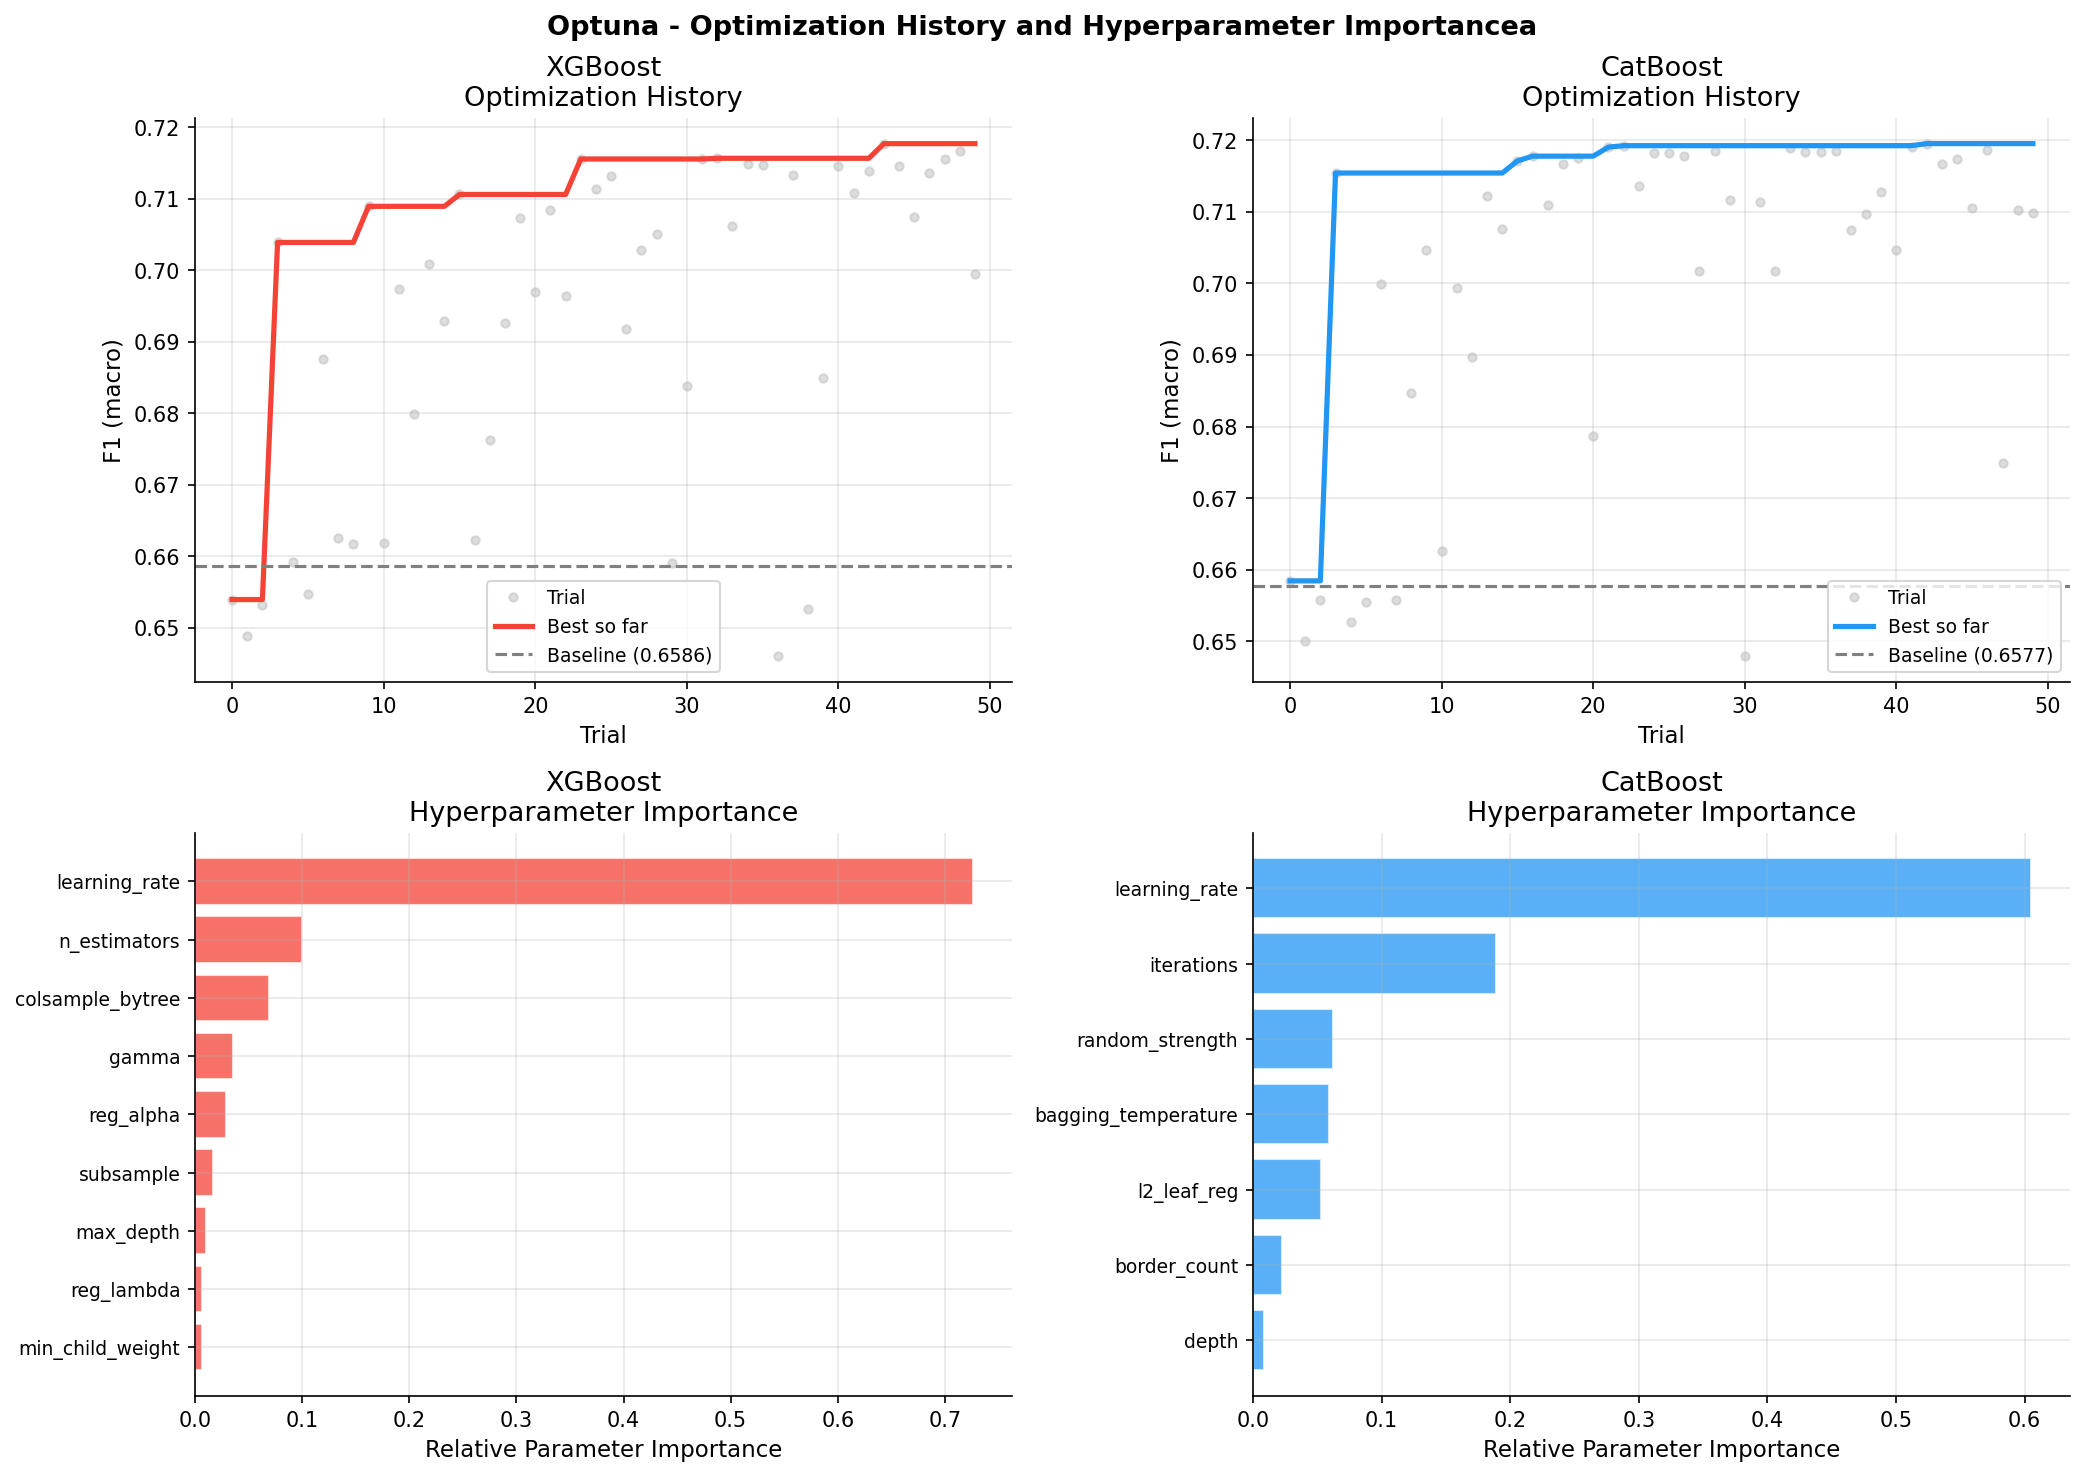

Sacuvano: figures/S5_optuna_analysis.png


In [13]:
# Optuna — vizualizacija optimizacije 

n_studies = len(optuna_studies)
if n_studies > 0:
    fig, axes = plt.subplots(2, n_studies, figsize=(7 * n_studies, 10))
    if n_studies == 1:
        axes = np.array(axes).reshape(2, 1)

    for col, (mname, study) in enumerate(optuna_studies.items()):
        trials_df = study.trials_dataframe()

        # Optimization history
        ax = axes[0, col]
        ax.plot(trials_df['number'], trials_df['value'],
                'o', color='#BDBDBD', alpha=0.5, markersize=4, label='Trial')
        best_so_far = trials_df['value'].cummax()
        ax.plot(trials_df['number'], best_so_far,
                '-', color=MODEL_COLORS.get(mname, '#333'), lw=2.5, label='Best so far')
        ax.axhline(y=main_f1_a[mname], color='grey', linestyle='--',
                   lw=1.5, label=f'Baseline ({main_f1_a[mname]:.4f})')
        ax.set_xlabel('Trial')
        ax.set_ylabel('F1 (macro)')
        ax.set_title(f'{mname}\nOptimization History')
        ax.legend(fontsize=11)

        # Parameter importances
        ax2 = axes[1, col]
        try:
            importances = optuna.importance.get_param_importances(study)
            params_sorted = list(importances.keys())[:10]
            vals_sorted = [importances[p] for p in params_sorted]
            ax2.barh(range(len(params_sorted)), vals_sorted[::-1],
                     color=MODEL_COLORS.get(mname, '#333'), alpha=0.75, edgecolor='white')
            ax2.set_yticks(range(len(params_sorted)))
            ax2.set_yticklabels(params_sorted[::-1], fontsize=11)
            ax2.set_xlabel('Relative Parameter Importance')
            ax2.set_title(f'{mname}\nHyperparameter Importance')
        except Exception:
            ax2.text(0.5, 0.5, 'Not enough trials for\nhyperparameter importance analysis',
                     ha='center', va='center', transform=ax2.transAxes)
            ax2.axis('off')

    plt.suptitle('Optuna - Optimization History and Hyperparameter Importance',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/S5_optuna_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sacuvano: figures/S5_optuna_analysis.png')

## 6. Finalna usporedna tabela - svi modeli zajedno

In [14]:
# Kombinovanje baseline + main + tuned rezultata 

main_df = pd.DataFrame(all_results)

# Dodaj 'Category' kolonu
def get_category(model_name):
    if 'tuned' in model_name.lower():
        return 'Tuned'
    return 'Main'

main_df['Category'] = main_df['Model'].apply(get_category)

# Dodaj kategoriju u baseline_df
bl_df = baseline_df.copy()
bl_df['Category'] = 'Baseline'

# Spoji sve
combined = pd.concat([bl_df, main_df], ignore_index=True)

# Redoslijed kategorija
cat_order = ['Baseline', 'Main', 'Tuned']
combined['Category'] = pd.Categorical(combined['Category'], categories=cat_order, ordered=True)
combined = combined.sort_values(['Dataset', 'Category', 'ROC-AUC'], ascending=[True, True, False])

# Ispis 

W3 = 106
HDR = (f'{"Kategorija":<12} {"Model":<24}'
       f'{"Accuracy":>9} {"Bal.Acc":>8}'
       f'{"Rec(HD)":>8} {"Prec(HD)":>9} {"F1(HD)":>7}'
       f'{"Spec":>7} {"F1mac":>7} {"ROC-AUC":>8} {"PR-AUC":>7}')

for ds in ['Dataset A', 'Dataset B']:
    ds_label = 'Dataset A - CDC 2022' if ds == 'Dataset A' else 'Dataset B - Heart Failure'
    sub = combined[combined['Dataset'] == ds]
    print()
    print('=' * W3)
    print(f'FINALNA USPOREDNA TABELA | {ds_label}')
    print('=' * W3)
    print(HDR)
    prev_cat = None
    for _, r in sub.iterrows():
        if r['Category'] != prev_cat:
            if prev_cat is not None:
                print('-' * W3)
            prev_cat = r['Category']
        print(
            f'{"[" + r["Category"] + "]":<12} {r["Model"]:<24}  '
            f'{r["Accuracy"]:>9.4f}  '
            f'{r["Balanced Accuracy"]:>8.4f}  '
            f'{r["Recall (HD)"]:>8.4f}  '
            f'{r["Precision (HD)"]:>9.4f}  '
            f'{r["F1 (HD)"]:>7.4f}  '
            f'{r["Specificity"]:>7.4f}  '
            f'{r["F1 (macro)"]:>7.4f}  '
            f'{r["ROC-AUC"]:>8.4f}  '
            f'{r["PR-AUC"]:>7.4f}'
        )
    print('=' * W3)

combined.to_csv('models/all_results.csv', index=False)
print()
print('Sacuvano: models/all_results.csv')


FINALNA USPOREDNA TABELA | Dataset A - CDC 2022
Kategorija   Model                    Accuracy  Bal.Acc Rec(HD)  Prec(HD)  F1(HD)   Spec   F1mac  ROC-AUC  PR-AUC
[Baseline]   Random Forest                0.9400    0.7038    0.4375     0.4666   0.4515   0.9701   0.7099    0.8791   0.3798
[Baseline]   Logistic Regression          0.8222    0.7952    0.7648     0.2078   0.3268   0.8256   0.6122    0.8780   0.3913
----------------------------------------------------------------------------------------------------------
[Main]       XGBoost                      0.9470    0.6180    0.2471     0.5706   0.3449   0.9889   0.6586    0.8865   0.4110
[Main]       CatBoost                     0.9478    0.6156    0.2411     0.5913   0.3426   0.9900   0.6577    0.8860   0.4203
[Main]       LightGBM                     0.9467    0.6129    0.2366     0.5673   0.3339   0.9892   0.6531    0.8858   0.4107
[Main]       TabNet                       0.8183    0.7798    0.7364     0.1994   0.3139   0.8232   

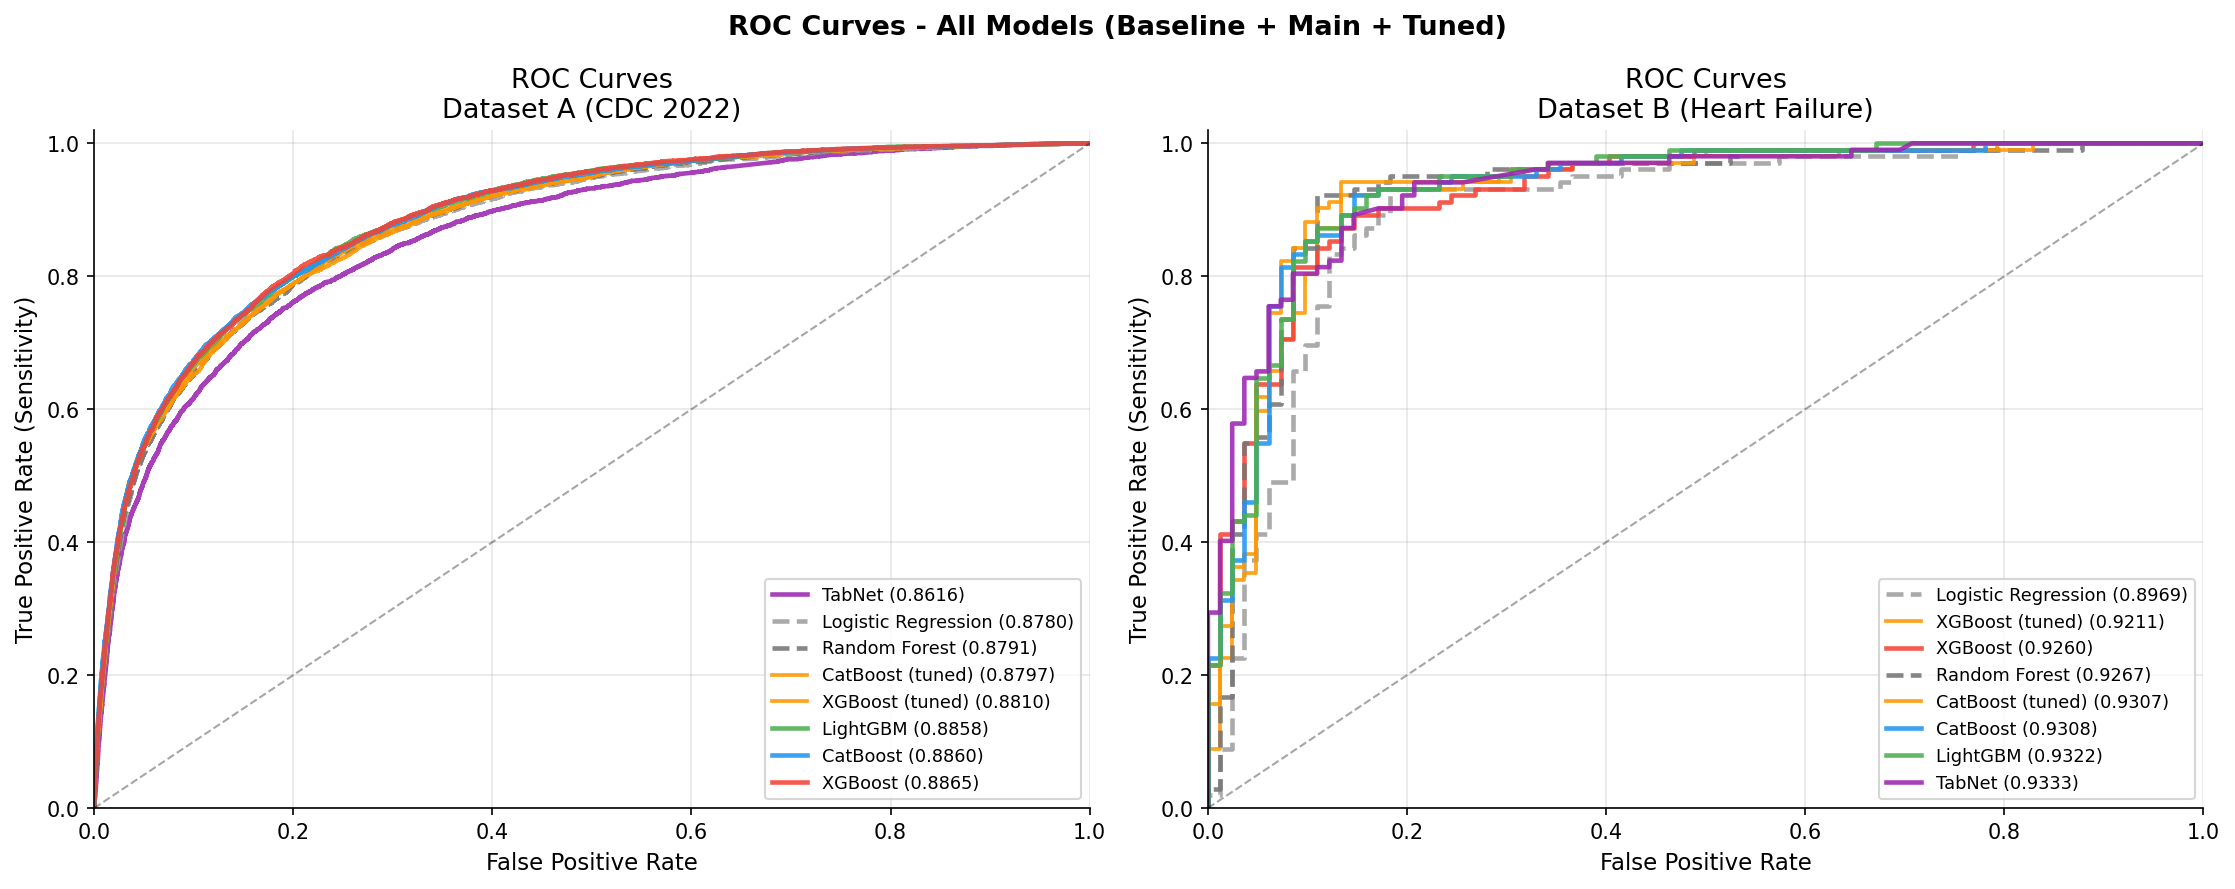

Sacuvano: figures/S5_roc_all_models.png


In [15]:
# ROC krivulje - svi modeli 

# Objedinjeni rjecnik sa svim krivuljama
all_vis = {**baseline_vis, **all_results_vis}

# Boje za baseline (sivo)
full_colors = {
    'Logistic Regression': '#9E9E9E', 'Random Forest': '#757575',
    'XGBoost': '#F44336', 'LightGBM': '#4CAF50',
    'CatBoost': '#2196F3', 'TabNet': '#9C27B0',
}
for name in list(all_vis.keys()):
    base = name.replace('_A', '').replace('_B', '')
    if base not in full_colors:
        full_colors[base] = '#FF9800'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (ds_key, ds_title) in zip(axes, [
    ('A', 'Dataset A (CDC 2022)'),
    ('B', 'Dataset B (Heart Failure)')
]):
    drawn = set()
    for key, m in sorted(all_vis.items(), key=lambda x: x[1].get('ROC-AUC', 0)):
        if not key.endswith(f'_{ds_key}'):
            continue
        mname = key.replace(f'_{ds_key}', '')
        if mname in drawn:
            continue
        drawn.add(mname)
        color = full_colors.get(mname, '#333333')
        ls = '--' if mname in ('Logistic Regression', 'Random Forest') else '-'
        lw = 1.8 if 'tuned' in mname.lower() else 2.2
        ax.plot(m['fpr'], m['tpr'],
                linestyle=ls, lw=lw, color=color, alpha=0.88,
                label=f'{mname} ({m["ROC-AUC"]:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.35)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    ax.set_title(f'ROC Curves\n{ds_title}')
    ax.legend(loc='lower right', fontsize=10.5)

plt.suptitle('ROC Curves - All Models (Baseline + Main + Tuned)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/S5_roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S5_roc_all_models.png')

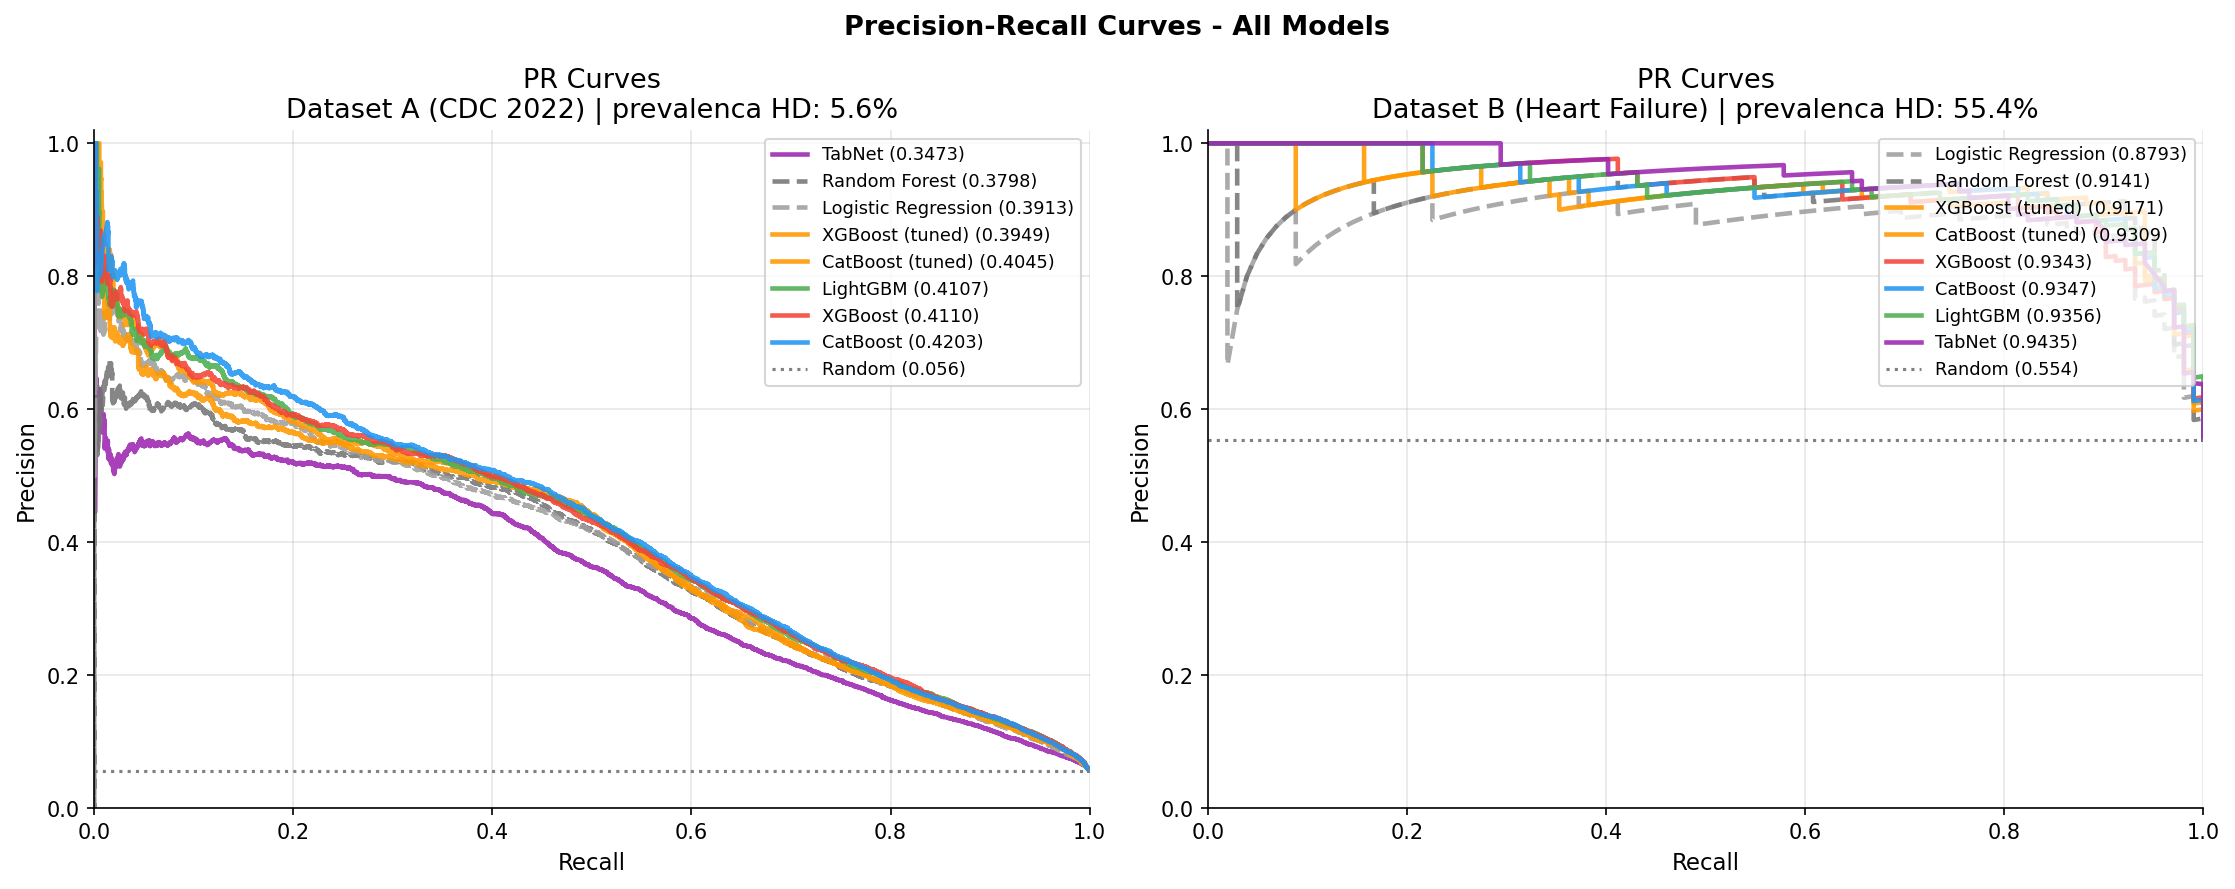

Sacuvano: figures/S5_pr_all_models.png


In [16]:
# PR krivulje - svi modeli 

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (ds_key, ds_title, y_te) in zip(axes, [
    ('A', 'Dataset A (CDC 2022)',      y_a_test),
    ('B', 'Dataset B (Heart Failure)', y_b_test)
]):
    prevalence = y_te.sum() / len(y_te)
    drawn = set()
    for key, m in sorted(all_vis.items(), key=lambda x: x[1].get('PR-AUC', 0)):
        if not key.endswith(f'_{ds_key}'):
            continue
        mname = key.replace(f'_{ds_key}', '')
        if mname in drawn:
            continue
        drawn.add(mname)
        color = full_colors.get(mname, '#333333')
        ls    = '--' if mname in ('Logistic Regression', 'Random Forest') else '-'
        ax.plot(m['recall_curve'], m['precision_curve'],
                linestyle=ls, lw=2.2, color=color, alpha=0.88,
                label=f'{mname} ({m["PR-AUC"]:.4f})')

    ax.axhline(y=prevalence, color='grey', linestyle=':', lw=1.5,
               label=f'Random ({prevalence:.3f})')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curves\n{ds_title} | HD prevalence: {prevalence:.1%}')
    ax.legend(loc='upper right', fontsize=10.5)

plt.suptitle('Precision-Recall Curves - All Models',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/S5_pr_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S5_pr_all_models.png')

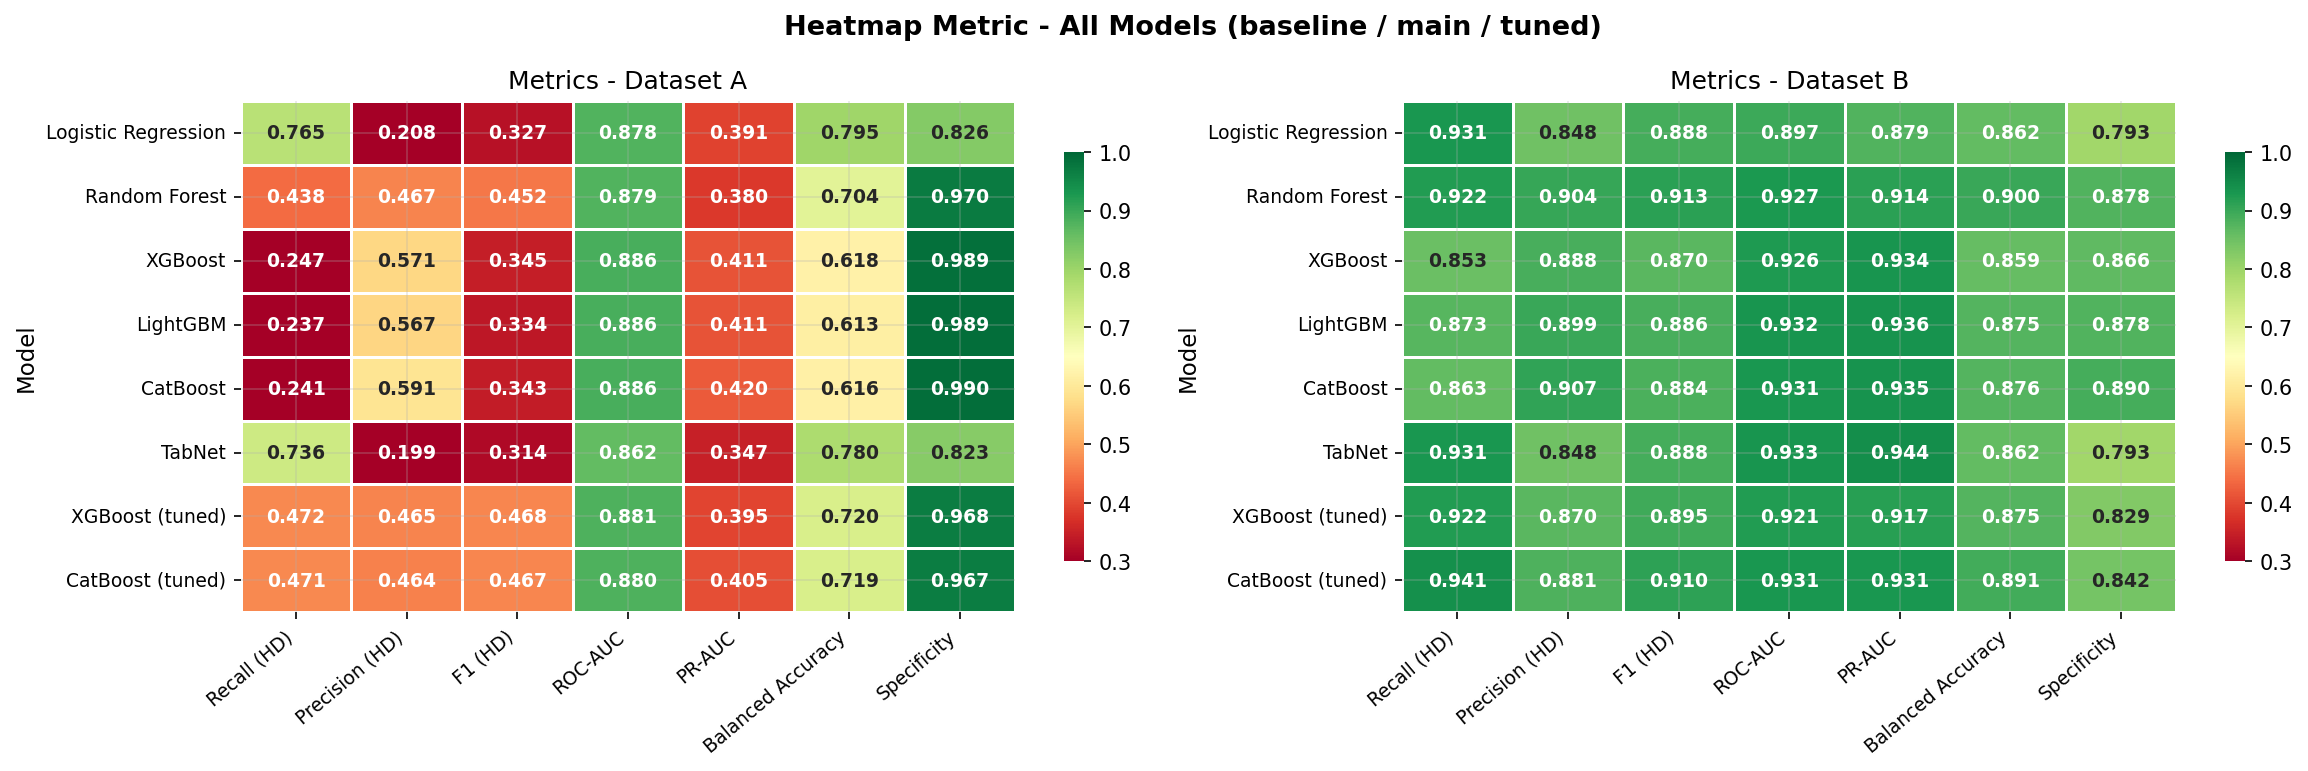

Sacuvano: figures/S5_metrics_heatmap_all.png


In [18]:
# Metrics heatmap — svi modeli

metric_cols = ['Recall (HD)', 'Precision (HD)', 'F1 (HD)',
               'ROC-AUC', 'PR-AUC', 'Balanced Accuracy', 'Specificity']

# Redoslijed prikaza
model_order = (
    baseline_df['Model'].tolist() +
    [m for m in main_df['Model'].tolist() if 'tuned' not in m.lower()] +
    [m for m in main_df['Model'].tolist() if 'tuned' in m.lower()]
)
model_order = list(dict.fromkeys(model_order))  # deduplikacija uz cuvanje reda

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(model_order) * 0.65)))

for ax, ds in zip(axes, ['Dataset A', 'Dataset B']):
    ds_data = combined[combined['Dataset'] == ds]
    sub = (
        ds_data.groupby('Model')[metric_cols].mean() 
        .reindex([m for m in model_order if m in ds_data['Model'].values])
    )
    sns.heatmap(
        sub, annot=True, fmt='.3f', cmap='RdYlGn',
        ax=ax, vmin=0.3, vmax=1.0, linewidths=0.5,
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': 11, 'weight': 'bold'}
    )
    ax.set_title(f'Metrics - {ds}', fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.suptitle('Heatmap Metric - All Models (baseline / main / tuned)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/S5_metrics_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S5_metrics_heatmap_all.png')

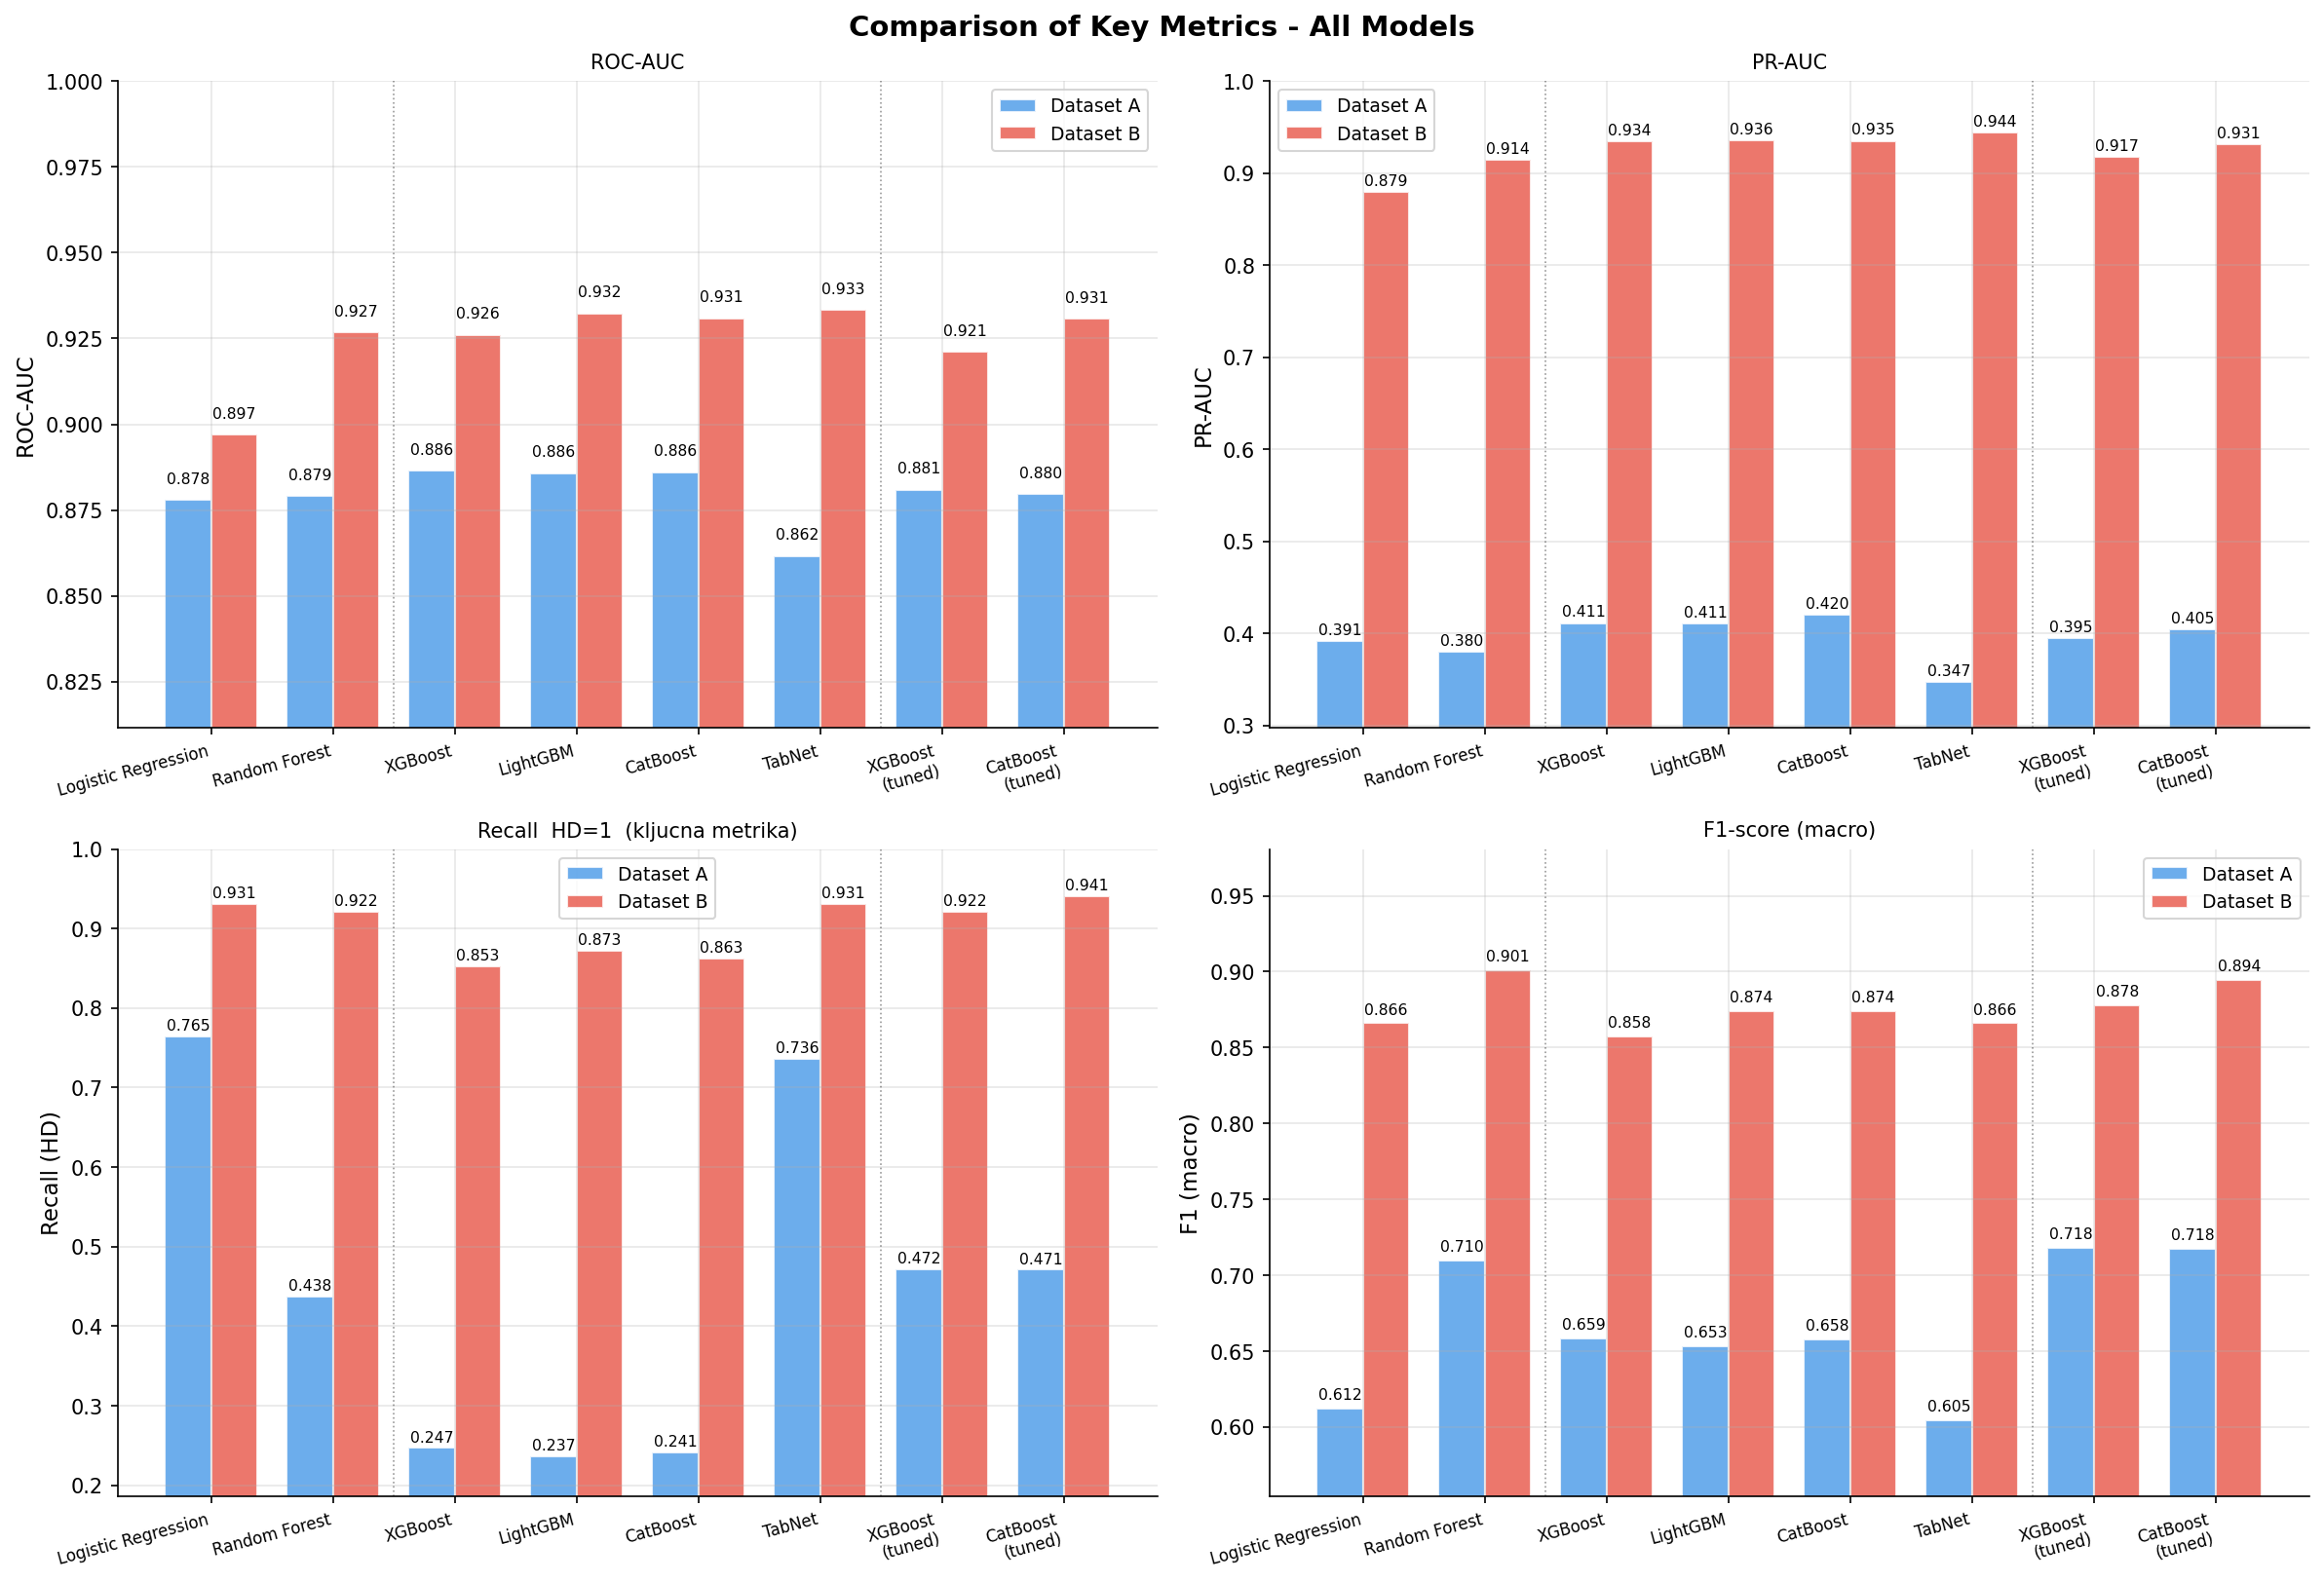

Sacuvano: figures/S5_metrics_comparison_all.png


In [19]:
# Bar charts: ROC-AUC, Recall(HD), F1(macro) po datasetu 

PLOT_METRICS = [
    ('ROC-AUC', 'ROC-AUC'),
    ('PR-AUC', 'PR-AUC'),
    ('Recall (HD)', 'Recall  HD=1  (kljucna metrika)'),
    ('F1 (macro)', 'F1-score (macro)'),
]

models_plot = [m for m in model_order
               if m in combined['Model'].values]
x = np.arange(len(models_plot))
width = 0.38

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (col, title) in zip(axes, PLOT_METRICS):
    va = []
    vb = []
    for m in models_plot:
        row_a = combined[(combined['Model'] == m) & (combined['Dataset'] == 'Dataset A')]
        row_b = combined[(combined['Model'] == m) & (combined['Dataset'] == 'Dataset B')]
        va.append(float(row_a[col].values[0]) if len(row_a) else 0)
        vb.append(float(row_b[col].values[0]) if len(row_b) else 0)

    bars_a = ax.bar(x - width / 2, va, width,
                    label='Dataset A', color=CLR_NEG, alpha=0.82, edgecolor='white')
    bars_b = ax.bar(x + width / 2, vb, width,
                    label='Dataset B', color=CLR_POS, alpha=0.82, edgecolor='white')

    for bar in list(bars_a) + list(bars_b):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2., h + 0.004,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=9.5)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [m.replace(' (tuned)', '\n(tuned)') for m in models_plot],
        fontsize=10, rotation=15, ha='right'
    )
    ax.set_ylabel(col)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=11)
    lo = max(0.0, min(va + vb) - 0.05)
    hi = min(1.0, max(va + vb) + 0.08)
    ax.set_ylim(lo, hi)

    # Vertikalne linije za odvajanje baseline / main / tuned
    n_base = len(baseline_df['Model'].unique())
    n_main = len([m for m in models_plot if 'tuned' not in m.lower() and
                  m not in baseline_df['Model'].values])
    for sep_x in [n_base - 0.5, n_base + n_main - 0.5]:
        if 0 < sep_x < len(models_plot) - 1:
            ax.axvline(x=sep_x, color='black', lw=0.8, alpha=0.4, linestyle=':')

plt.suptitle('Comparison of Key Metrics - All Models',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/S5_metrics_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S5_metrics_comparison_all.png')

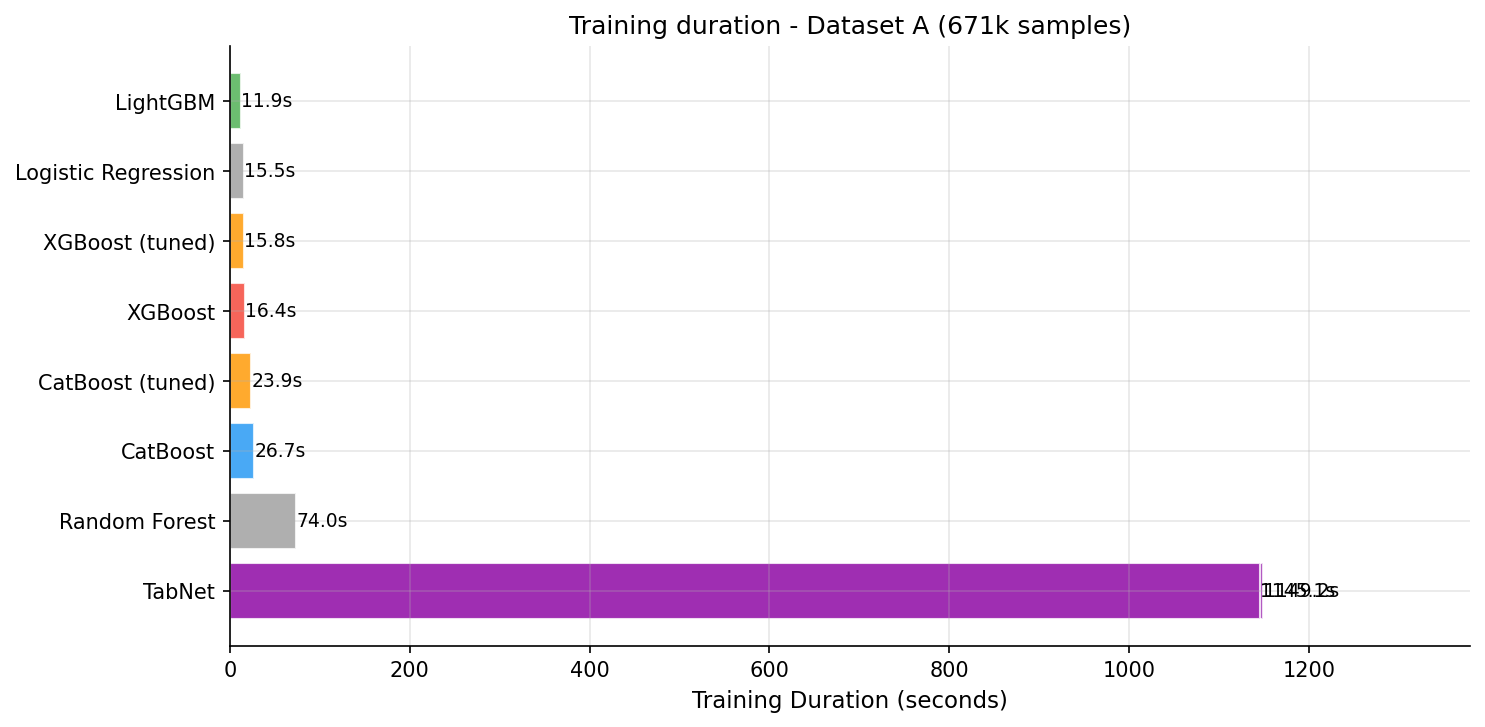

Sacuvano: figures/S5_training_time.png


In [20]:
# Training time usporedba 

time_cols = ['Model', 'Dataset', 'train_time']
time_df = combined[combined['train_time'].notna()][time_cols].copy()

# Samo Dataset A za preglednost (671k > 734)
time_a = time_df[time_df['Dataset'] == 'Dataset A'].sort_values('train_time', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, len(time_a) * 0.55)))
colors_t = [
    '#9E9E9E' if m in baseline_df['Model'].values
    else ('#FF9800' if 'tuned' in m.lower() else full_colors.get(m, '#607D8B'))
    for m in time_a['Model']
]
bars = ax.barh(time_a['Model'], time_a['train_time'],
               color=colors_t, alpha=0.82, edgecolor='white')
for bar, val in zip(bars, time_a['train_time']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2.,
            f'{val:.1f}s', va='center', fontsize=11)
ax.set_xlabel('Training Duration (seconds)')
ax.set_title('Training duration - Dataset A (671k samples)', fontsize=14)
ax.set_xlim(0, time_a['train_time'].max() * 1.2)

plt.tight_layout()
plt.savefig('figures/S5_training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S5_training_time.png')

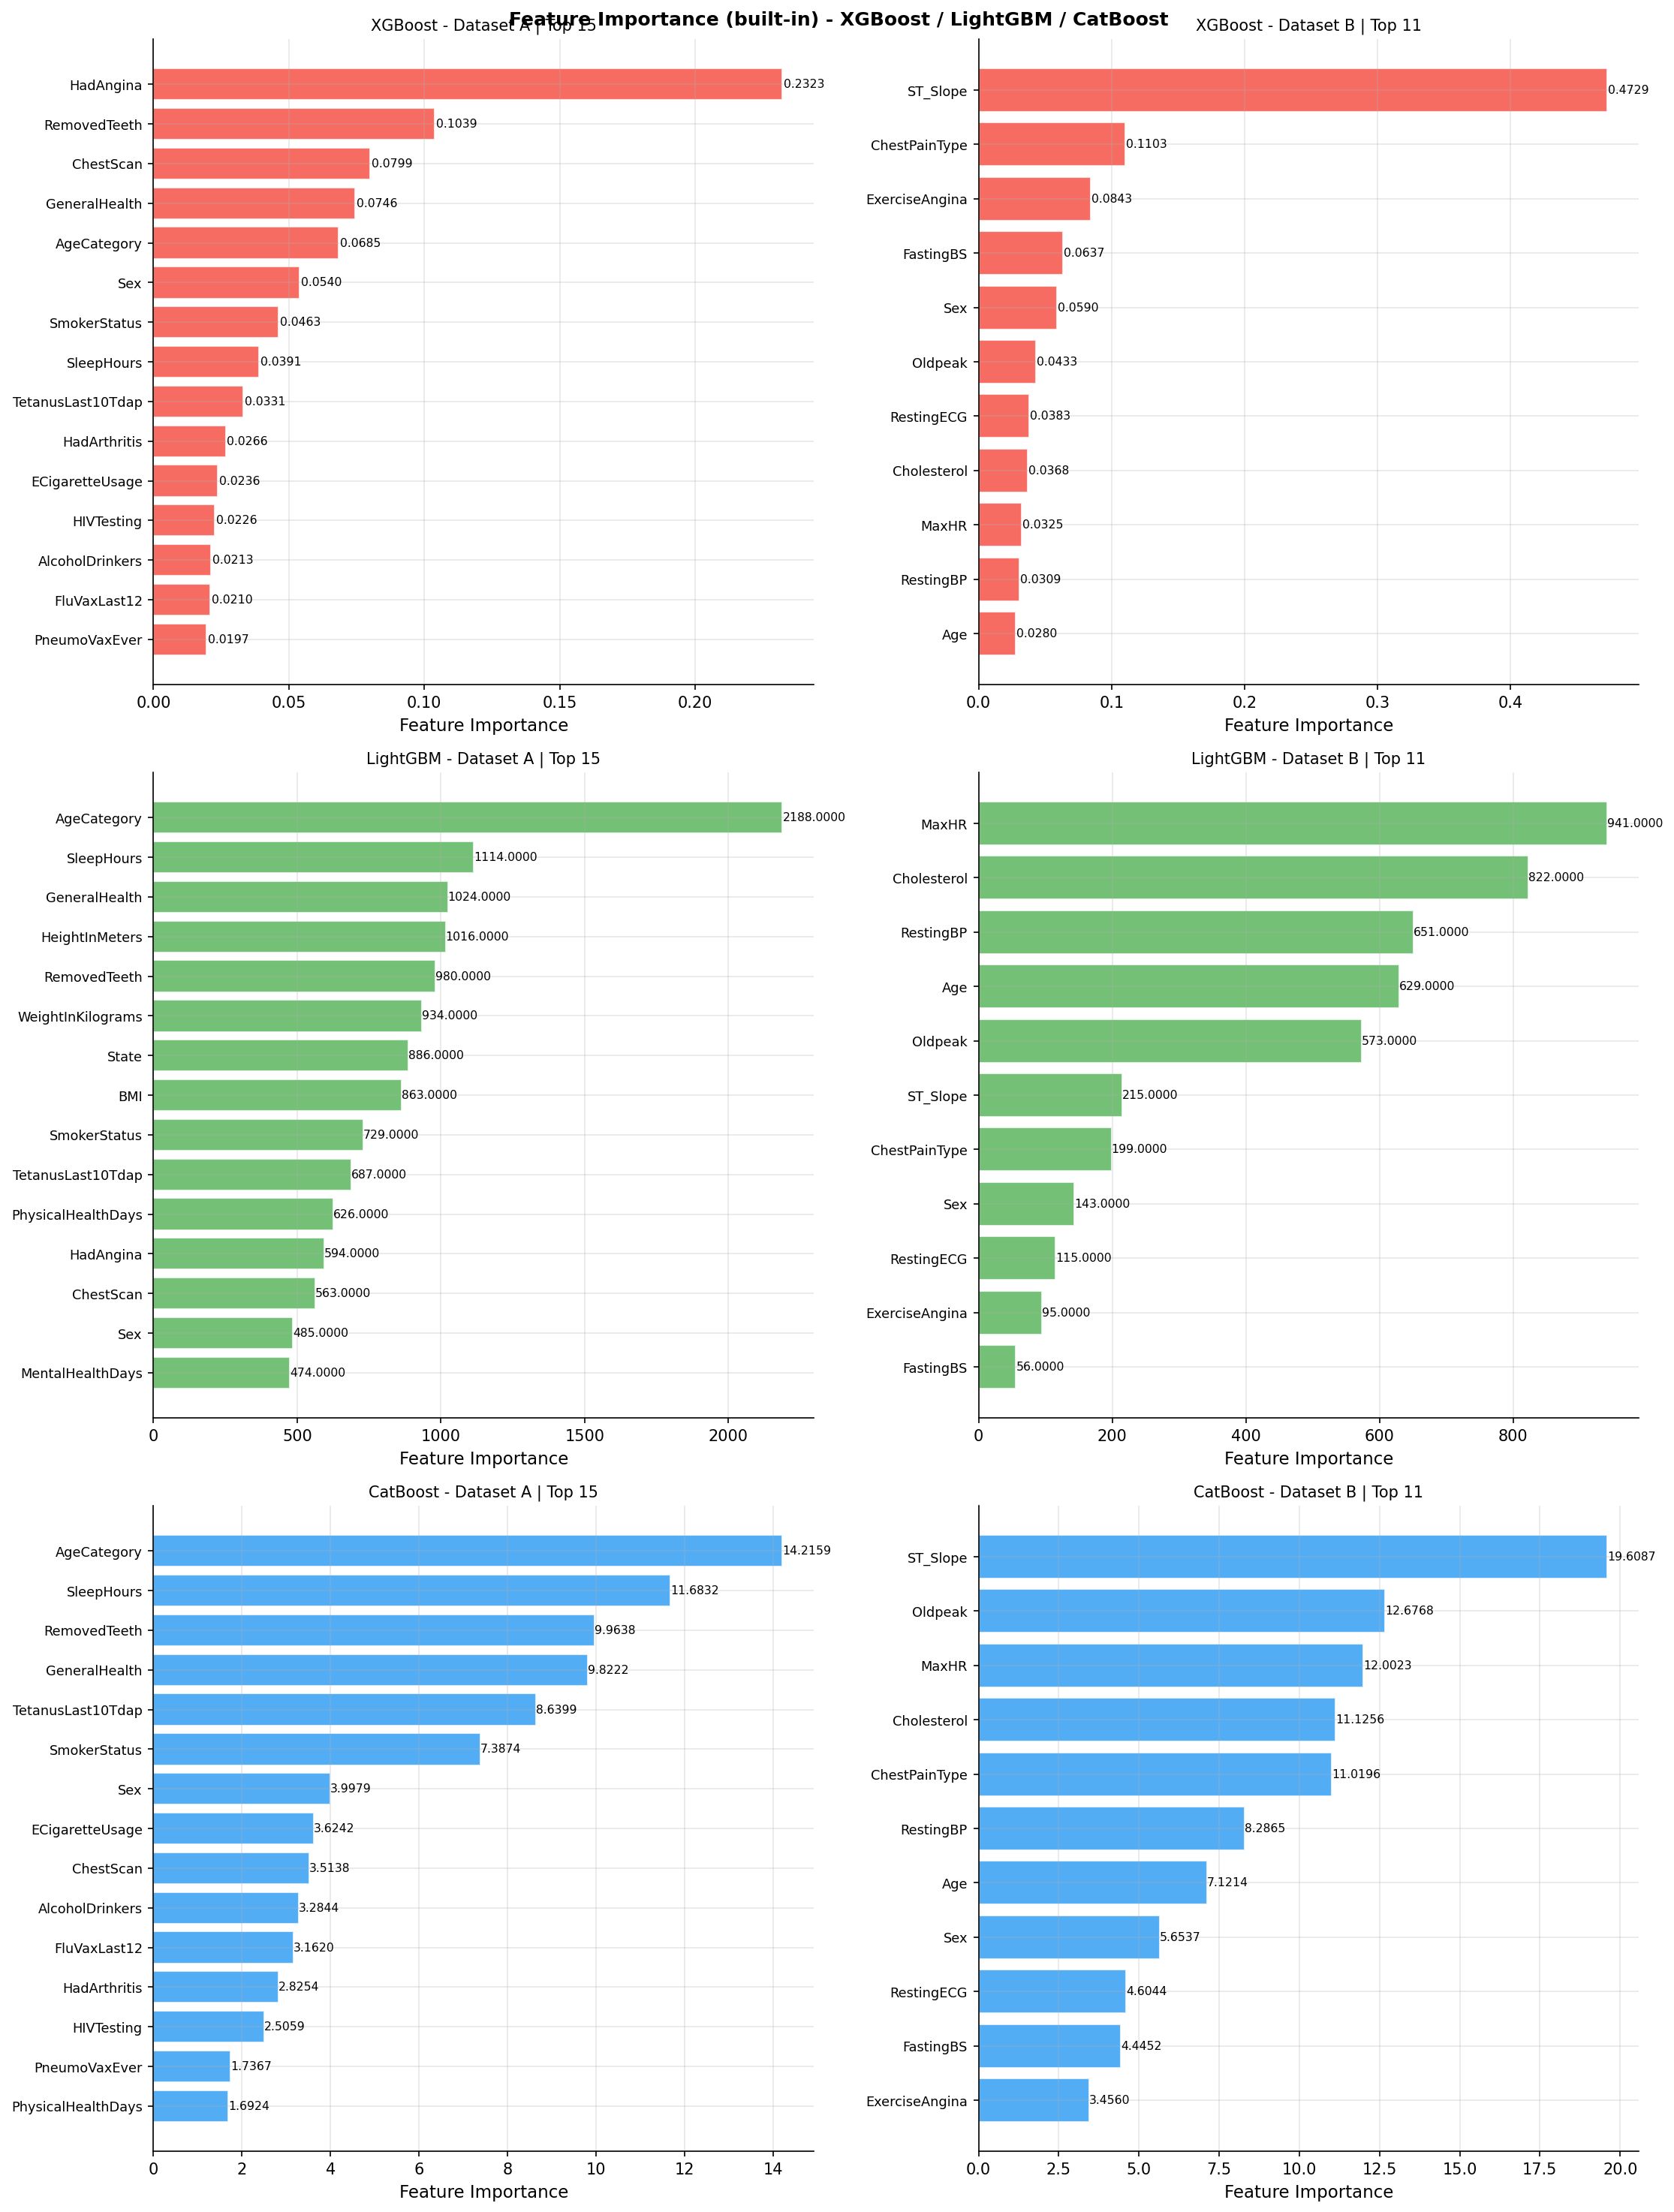

Sacuvano: figures/S5_feature_importance.png


In [25]:
# Feature Importance (tree-based modeli) 

TOP_N = 15

fi_configs = [
    ('XGBoost', xgb_a, feature_names_a, 'Dataset A', MODEL_COLORS['XGBoost']),
    ('XGBoost', xgb_b, feature_names_b, 'Dataset B', MODEL_COLORS['XGBoost']),
    ('LightGBM', lgbm_a, feature_names_a, 'Dataset A', MODEL_COLORS['LightGBM']),
    ('LightGBM', lgbm_b, feature_names_b, 'Dataset B', MODEL_COLORS['LightGBM']),
    ('CatBoost', cat_a, feature_names_a, 'Dataset A', MODEL_COLORS['CatBoost']),
    ('CatBoost', cat_b, feature_names_b, 'Dataset B', MODEL_COLORS['CatBoost']),
]

fig, axes = plt.subplots(3, 2, figsize=(15, 20))

for ax, (mname, clf, feat_names, ds_label, color) in zip(axes.flatten(), fi_configs):
    importances = clf.feature_importances_
    n = min(TOP_N, len(feat_names))  
    idx = np.argsort(importances)[::-1][:n]
    top_feats = [feat_names[i] for i in idx]
    top_vals = importances[idx]

    ax.barh(range(n), top_vals[::-1], color=color, alpha=0.78, edgecolor='white')
    ax.set_yticks(range(n))
    ax.set_yticklabels(top_feats[::-1], fontsize=10.5)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{mname} - {ds_label} | Top {n}', fontsize=12)
    for i, val in enumerate(top_vals[::-1]):
        ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=9.5)

plt.suptitle('Feature Importance (built-in) - XGBoost / LightGBM / CatBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/S5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S5_feature_importance.png')

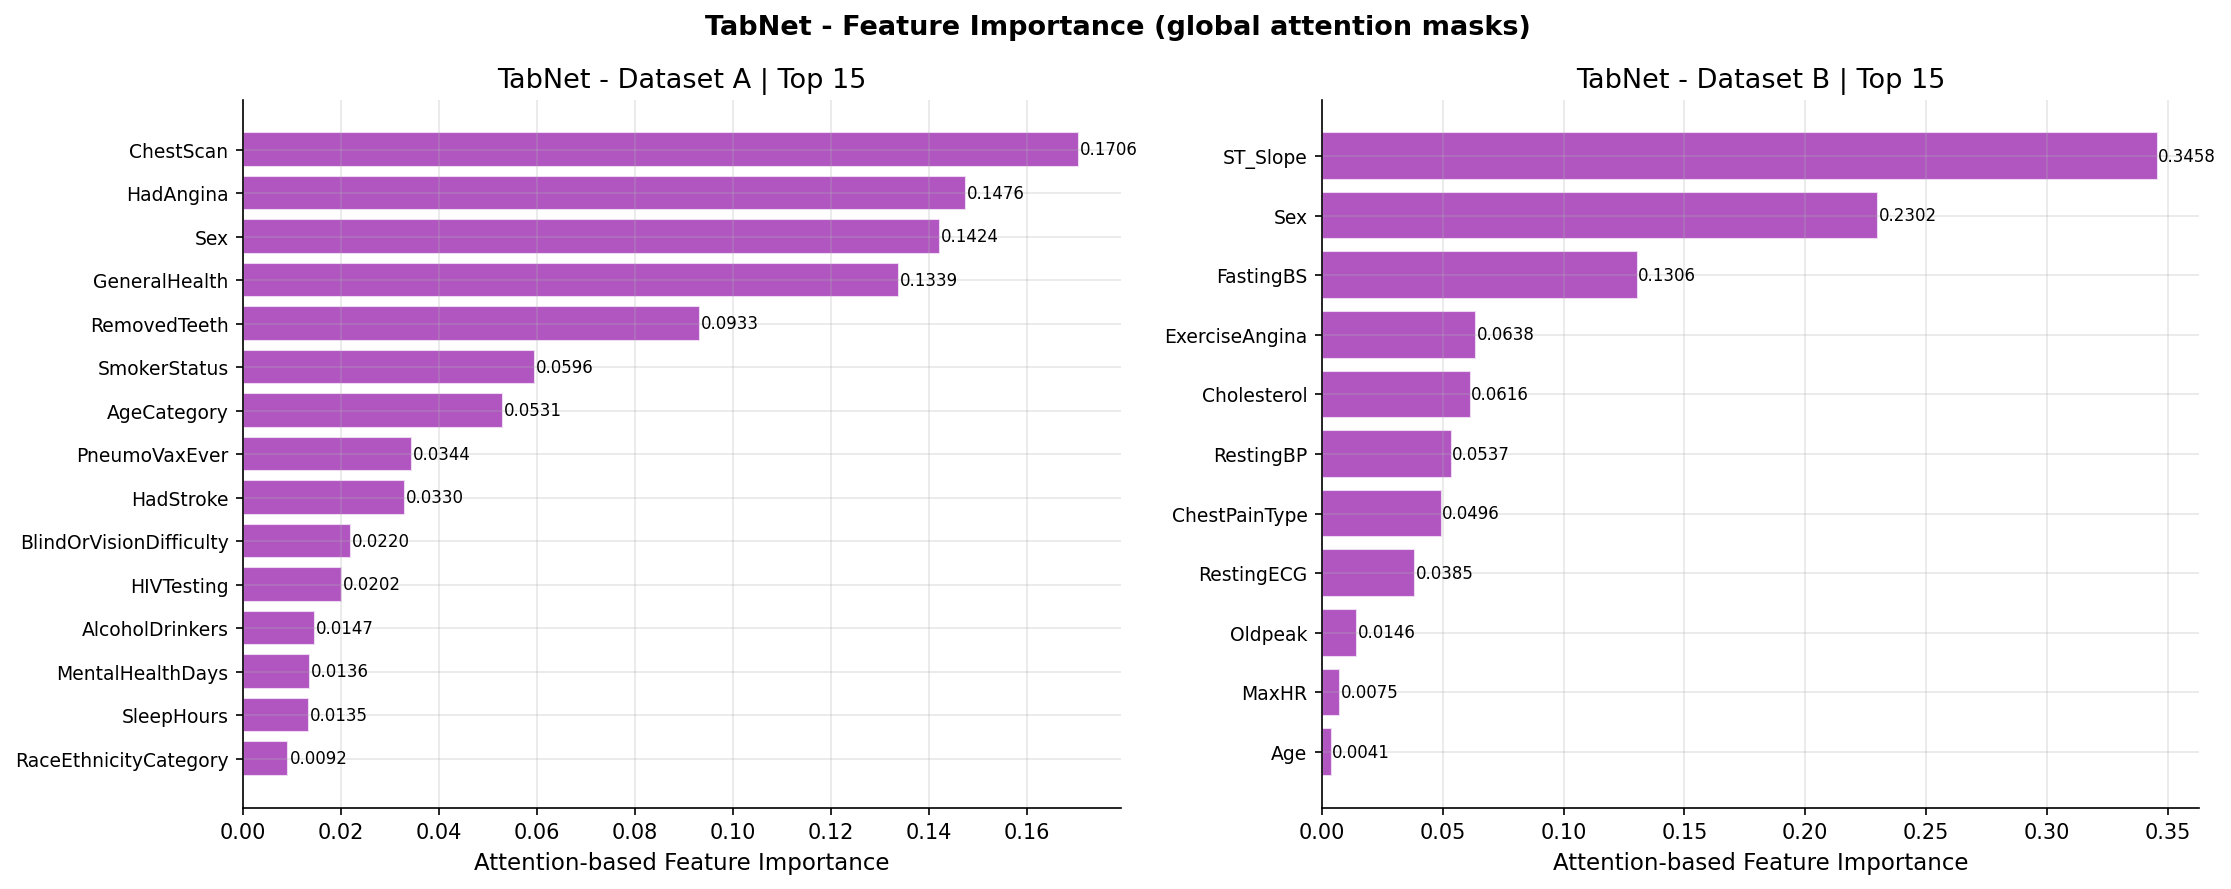

Sacuvano: figures/S5_tabnet_feature_importance.png


In [26]:
# TabNet: globalna vaznost featura (attention masks)

if TABNET_OK:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, (clf, feat_names, ds_label) in zip(axes, [
        (tab_a, feature_names_a, 'Dataset A'),
        (tab_b, feature_names_b, 'Dataset B'),
    ]):
        fi = clf.feature_importances_
        idx = np.argsort(fi)[::-1][:15]
        top_f = [feat_names[i] for i in idx]
        top_v = fi[idx]

        ax.barh(range(len(top_f)), top_v[::-1],
                color=MODEL_COLORS['TabNet'], alpha=0.78, edgecolor='white')
        ax.set_yticks(range(len(top_f)))
        ax.set_yticklabels(top_f[::-1], fontsize=11)
        ax.set_xlabel('Attention-based Feature Importance')
        ax.set_title(f'TabNet - {ds_label} | Top 15')
        for i, val in enumerate(top_v[::-1]):
            ax.text(val + 0.0002, i, f'{val:.4f}', va='center', fontsize=10)

    plt.suptitle('TabNet - Feature Importance (global attention masks)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/S5_tabnet_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sacuvano: figures/S5_tabnet_feature_importance.png')
else:
    print('TabNet nije dostupan - preskocen prikaz feature importances.')

## 7. Čuvanje modela

In [27]:
main_output = {
    # Modeli
    'models_a': {**models_a, **tuned_models_a},
    'models_b': {**models_b, **tuned_models_b},

    # Rezultati
    'results_df': main_df,
    'combined_df': combined, # baseline + main + tuned
    'all_results_vis': all_results_vis,

    # Tuning
    'best_params': best_params,
    'optuna_studies': optuna_studies,
    'top2_models': TOP2,

    # Metapodaci
    'model_names': list(models_a.keys()),
    'feature_names_a': feature_names_a,
    'feature_names_b': feature_names_b,
}

with open('models/main_models.pkl', 'wb') as f:
    pickle.dump(main_output, f)

print('Sacuvano: models/main_models.pkl')
print()
print(f'models_a: {list(main_output["models_a"].keys())}')
print(f'models_b: {list(main_output["models_b"].keys())}')
print(f'combined_df: {combined.shape}')
print(f'top2 tuned: {TOP2}')
print()
print('S5 -- Main Models: ZAVRSEN!')

Sacuvano: models/main_models.pkl

models_a: ['XGBoost', 'LightGBM', 'CatBoost', 'TabNet', 'XGBoost (tuned)', 'CatBoost (tuned)']
models_b: ['XGBoost', 'LightGBM', 'CatBoost', 'TabNet', 'XGBoost (tuned)', 'CatBoost (tuned)']
combined_df: (18, 22)
top2 tuned: ['XGBoost', 'CatBoost']

S5 -- Main Models: ZAVRSEN!


## Zaključak — S5

U ovom notebooku implementirana su četiri napredna modela (XGBoost, LightGBM, CatBoost, TabNet) s hyperparameter tuning-om top-2 modela putem Optune.

### Napomene za interpretaciju
- **Recall (HD=1)** ostaje primarna metrika — minimizacija lažno negativnih predikcija
- **PR-AUC** je pouzdanija od ROC-AUC na neuravnoteženom Dataset A
- Tuning je rađen na poduzorku za računsku efikasnost, finalni modeli trenirani na punom skupu
- Feature importance prikazan je kao preview